## SPARK: OVERVIEW
- Apache Spark is a distributed engine for large-scale data processing
- Spark DataFrames are the main abstraction used for structured data
- It supports SQL, batch processing, streaming, and machine learning
- Core documentation: https://spark.apache.org/docs/latest/
- PySpark API reference: https://spark.apache.org/docs/latest/api/python/

## Spark DataFrame basics
Spark usa DataFrame come struttura principale per dati strutturati distribuiti.
Per una collezione monodimensionale etichettata si usa un DataFrame a singola colonna.
Le trasformazioni sono ottimizzate dal motore Catalyst.
Pattern base di creazione: `spark.createDataFrame(data, schema=...)`

In [124]:
%%time

%pip install pyspark==4.1.2 pandas numpy neo4j redis hiredis PyArrow>=15.0.0 graphframes grpcio grpcio-status zstandard

Note: you may need to restart the kernel to use updated packages.
CPU times: user 60.7 ms, sys: 36 ms, total: 96.7 ms
Wall time: 2.17 s


In [125]:
%%time

# connect
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark.sql import Row
import os
import tempfile
import urllib.request
from pathlib import Path
from pyspark import SparkContext

WORK_TMP_DIR = str(Path('/tmp/.spark-tmp').resolve())
os.makedirs(WORK_TMP_DIR, exist_ok=True)




def create_sail_session(
    app_name: str = "FlightPreprocessSpark",
    driver_bind_address: str = "0.0.0.0",
) -> "SparkSession":
    """
    Create a Spark session with the same network settings used in 00-hello-test.py.
    """
    from pyspark.sql import SparkSession

    return (
        SparkSession.builder
        .appName(app_name)
        .remote("sc://10.0.0.79:6066")
        .config("spark.driver.bindAddress", driver_bind_address)
        .config("spark.local.dir", WORK_TMP_DIR)
        .config("spark.jars.packages", "io.graphframes:graphframes-spark4_2.13:0.9.3")
        .getOrCreate()
    )


def read_csv_any(path: str):
    if path.startswith('http://') or path.startswith('https://'):
        local_path = os.path.join(WORK_TMP_DIR, os.path.basename(path))
        urllib.request.urlretrieve(path, local_path)
        path = local_path
    df = spark.read.option('header', True).option('inferSchema', True).csv(path)
    # If CSV header had an empty first column name, rename it to 'row_id' to avoid warnings
    cols = df.columns
    if len(cols) > 0 and (cols[0] == '' or cols[0] is None):
        df = df.withColumnRenamed(cols[0], 'row_id')
    # Also normalize common generated name _c0 to 'row_id' for consistency
    if 'row_id' not in df.columns and '_c0' in df.columns:
        df = df.withColumnRenamed('_c0', 'row_id')
    return df

CPU times: user 1.65 ms, sys: 0 ns, total: 1.65 ms
Wall time: 1.26 ms


In [126]:
%%time

# Creating a one-column Spark DataFrame
spark = create_sail_session('One column DataFrame')
data = [('b', 1), ('a', 0), ('c', 2)]
s = spark.createDataFrame(data, ['key', 'value'])
s.show()

+---+-----+
|key|value|
+---+-----+
|  b|    1|
|  a|    0|
|  c|    2|
+---+-----+

CPU times: user 11.5 ms, sys: 6.03 ms, total: 17.5 ms
Wall time: 17.4 ms


In [127]:
%%time

s = spark.createDataFrame([('A', 5.0), ('B', 6.0), ('C', 12.0), ('D', 1.3)], ['index', 'serie_0'])
s.show()


+-----+-------+
|index|serie_0|
+-----+-------+
|    A|    5.0|
|    B|    6.0|
|    C|   12.0|
|    D|    1.3|
+-----+-------+

CPU times: user 9.6 ms, sys: 2.23 ms, total: 11.8 ms
Wall time: 11.8 ms


In [128]:
%%time

# series access
s.limit(2).show()

+-----+-------+
|index|serie_0|
+-----+-------+
|    A|    5.0|
|    B|    6.0|
+-----+-------+

CPU times: user 7.02 ms, sys: 3.19 ms, total: 10.2 ms
Wall time: 8.91 ms


## Spark DataFrame
- I DataFrame Spark sono tabelle distribuite gestite dal cluster
- Sono l'astrazione principale per i dati strutturati in PySpark
- Un DataFrame a singola colonna copre i casi monodimensionali
- Creazione tipica: `spark.createDataFrame(data, schema)`

In [129]:
%%time

spark = create_sail_session("Key-tuple DataFrame")

spark.createDataFrame([('A', 0.0), ('B', 4.0), ('C', 8.0), ('D', -12.0), ('E', 16.0)], ['key', 'foo']).show()

+---+-----+
|key|  foo|
+---+-----+
|  A|  0.0|
|  B|  4.0|
|  C|  8.0|
|  D|-12.0|
|  E| 16.0|
+---+-----+

CPU times: user 11.9 ms, sys: 5.14 ms, total: 17.1 ms
Wall time: 17.7 ms


Hands-on excercise (slide 29)

In [130]:
%%time

spark = create_sail_session("Tuple List DataFrame")

spark.createDataFrame([(1, 3), (2, 4), (6, 5)], ['foo', 'fee']).show()

+---+---+
|foo|fee|
+---+---+
|  1|  3|
|  2|  4|
|  6|  5|
+---+---+

CPU times: user 14.6 ms, sys: 488 μs, total: 15 ms
Wall time: 15.3 ms


In [131]:
%%time

spark = create_sail_session("None Values DataFrame")

spark.createDataFrame([('a', 1, None), ('b', 1, None), ('c', None, 1), ('d', None, 2)], ['idx', 'foo', 'fee']).show()

+---+----+----+
|idx| foo| fee|
+---+----+----+
|  a|   1|NULL|
|  b|   1|NULL|
|  c|NULL|   1|
|  d|NULL|   2|
+---+----+----+

CPU times: user 13.5 ms, sys: 2.35 ms, total: 15.9 ms
Wall time: 16 ms


## Spark DataFrame schema
Spark espone uno schema tipizzato con nomi colonna, tipi e nullability.
Usa `printSchema()` per l'ispezione strutturale.
Usa `select`, `filter`, `withColumn` e `groupBy` per trasformare i dati.

## Spark data types
- `IntegerType` and `LongType` for integers
- `FloatType`, `DoubleType`, and `DecimalType` for numeric values
- `BooleanType` for booleans
- `DateType` and `TimestampType` for temporal data
- `StringType` for text
- `ArrayType`, `MapType`, and `StructType` for nested structures

- `byte`, `short`, `integer`, `long`: signed integral types
- `float`, `double`, `decimal`: numeric types with fractional support
- `boolean`: logical values
- `date`, `timestamp`: date and time types
- `string`: textual data
- `binary`: raw bytes
- `array`, `map`, `struct`: nested types for complex data

### Spark DataFrame attributes
- `df.columns` lists column names
- `df.dtypes` returns the Spark type of each column
- `df.schema` returns the full schema object
- `df.columns`, `df.count()`, and `df.printSchema()` are the most common inspection tools
- `df.rdd` exposes the underlying RDD when lower-level access is needed

### Spark DataFrame methods
- `show(n)`, `limit(n)`: preview rows
- `describe()`, `summary()`: descriptive statistics
- `select()`, `filter()`, `where()`: project and filter data
- `dropna()`, `fillna()`: handle missing values
- `distinct()`, `dropDuplicates()`: remove duplicates
- `groupBy()`, `agg()`, `count()`: aggregate data

In [132]:
%%time

# Ispezione schema-driven con Spark
spark = create_sail_session('schema-driven inspection')

spark.range(1).show()

+---+
| id|
+---+
|  0|
+---+

CPU times: user 11.8 ms, sys: 1.23 ms, total: 13.1 ms
Wall time: 12.2 ms


In [133]:
%%time

from pyspark.sql import Row
from pyspark.sql import types as T
spark = create_sail_session()

data = [
    Row(Colonna1=1, Colonna2=5.1, Colonna3='2022-01-01', Colonna4='A', Colonna5=True),
    Row(Colonna1=2, Colonna2=6.2, Colonna3='2022-02-01', Colonna4='B', Colonna5=False),
    Row(Colonna1=3, Colonna2=7.3, Colonna3='2022-03-01', Colonna4='A', Colonna5=True),
    Row(Colonna1=4, Colonna2=8.4, Colonna3='2022-04-01', Colonna4='C', Colonna5=False),
]

df = spark.createDataFrame(data)
df.show()

+--------+--------+----------+--------+--------+
|Colonna1|Colonna2|  Colonna3|Colonna4|Colonna5|
+--------+--------+----------+--------+--------+
|       1|     5.1|2022-01-01|       A|    true|
|       2|     6.2|2022-02-01|       B|   false|
|       3|     7.3|2022-03-01|       A|    true|
|       4|     8.4|2022-04-01|       C|   false|
+--------+--------+----------+--------+--------+

CPU times: user 11.1 ms, sys: 5.98 ms, total: 17 ms
Wall time: 18.7 ms


In [134]:
%%time

df.printSchema()

root
 |-- Colonna1: long (nullable = true)
 |-- Colonna2: double (nullable = true)
 |-- Colonna3: string (nullable = true)
 |-- Colonna4: string (nullable = true)
 |-- Colonna5: boolean (nullable = true)

CPU times: user 4.21 ms, sys: 1.17 ms, total: 5.39 ms
Wall time: 4.95 ms


In [135]:
%%time

df = df.withColumn('Colonna1', F.col('Colonna1').cast('double'))
df.show()

+--------+--------+----------+--------+--------+
|Colonna1|Colonna2|  Colonna3|Colonna4|Colonna5|
+--------+--------+----------+--------+--------+
|     1.0|     5.1|2022-01-01|       A|    true|
|     2.0|     6.2|2022-02-01|       B|   false|
|     3.0|     7.3|2022-03-01|       A|    true|
|     4.0|     8.4|2022-04-01|       C|   false|
+--------+--------+----------+--------+--------+

CPU times: user 8.44 ms, sys: 1.32 ms, total: 9.77 ms
Wall time: 13.3 ms


In [136]:
%%time

df = df.withColumn('Colonna2', F.col('Colonna2').cast('int'))
df.show()

+--------+--------+----------+--------+--------+
|Colonna1|Colonna2|  Colonna3|Colonna4|Colonna5|
+--------+--------+----------+--------+--------+
|     1.0|       5|2022-01-01|       A|    true|
|     2.0|       6|2022-02-01|       B|   false|
|     3.0|       7|2022-03-01|       A|    true|
|     4.0|       8|2022-04-01|       C|   false|
+--------+--------+----------+--------+--------+

CPU times: user 8.29 ms, sys: 4.87 ms, total: 13.2 ms
Wall time: 15.1 ms


In [137]:
%%time

df = df.withColumn('Colonna3', F.to_date('Colonna3'))
df.printSchema()
df.show()


root
 |-- Colonna1: double (nullable = true)
 |-- Colonna2: integer (nullable = true)
 |-- Colonna3: date (nullable = true)
 |-- Colonna4: string (nullable = true)
 |-- Colonna5: boolean (nullable = true)

+--------+--------+----------+--------+--------+
|Colonna1|Colonna2|  Colonna3|Colonna4|Colonna5|
+--------+--------+----------+--------+--------+
|     1.0|       5|2022-01-01|       A|    true|
|     2.0|       6|2022-02-01|       B|   false|
|     3.0|       7|2022-03-01|       A|    true|
|     4.0|       8|2022-04-01|       C|   false|
+--------+--------+----------+--------+--------+

CPU times: user 14.8 ms, sys: 2.51 ms, total: 17.3 ms
Wall time: 19.8 ms


In [138]:
%%time

# 4. Convertire la Colonna3 da data a stringa (Spark)
df = df.withColumn('Colonna3', F.date_format(F.col('Colonna3'), 'yyyy-MM-dd'))
df.printSchema()
df.show()

root
 |-- Colonna1: double (nullable = true)
 |-- Colonna2: integer (nullable = true)
 |-- Colonna3: string (nullable = true)
 |-- Colonna4: string (nullable = true)
 |-- Colonna5: boolean (nullable = true)

+--------+--------+----------+--------+--------+
|Colonna1|Colonna2|  Colonna3|Colonna4|Colonna5|
+--------+--------+----------+--------+--------+
|     1.0|       5|2022-01-01|       A|    true|
|     2.0|       6|2022-02-01|       B|   false|
|     3.0|       7|2022-03-01|       A|    true|
|     4.0|       8|2022-04-01|       C|   false|
+--------+--------+----------+--------+--------+

CPU times: user 12 ms, sys: 4.88 ms, total: 16.9 ms
Wall time: 22 ms


In [139]:
%%time

# 5. Colonna4 come stringa (Spark non usa dtype category)
df = df.withColumn('Colonna4', F.col('Colonna4').cast('string'))
df.printSchema()
df.show()

root
 |-- Colonna1: double (nullable = true)
 |-- Colonna2: integer (nullable = true)
 |-- Colonna3: string (nullable = true)
 |-- Colonna4: string (nullable = true)
 |-- Colonna5: boolean (nullable = true)

+--------+--------+----------+--------+--------+
|Colonna1|Colonna2|  Colonna3|Colonna4|Colonna5|
+--------+--------+----------+--------+--------+
|     1.0|       5|2022-01-01|       A|    true|
|     2.0|       6|2022-02-01|       B|   false|
|     3.0|       7|2022-03-01|       A|    true|
|     4.0|       8|2022-04-01|       C|   false|
+--------+--------+----------+--------+--------+

CPU times: user 14 ms, sys: 845 μs, total: 14.8 ms
Wall time: 20.4 ms


In [140]:
%%time

df = df.withColumn('Colonna4', F.col('Colonna4').cast('string'))
df.printSchema()
df.show()

root
 |-- Colonna1: double (nullable = true)
 |-- Colonna2: integer (nullable = true)
 |-- Colonna3: string (nullable = true)
 |-- Colonna4: string (nullable = true)
 |-- Colonna5: boolean (nullable = true)

+--------+--------+----------+--------+--------+
|Colonna1|Colonna2|  Colonna3|Colonna4|Colonna5|
+--------+--------+----------+--------+--------+
|     1.0|       5|2022-01-01|       A|    true|
|     2.0|       6|2022-02-01|       B|   false|
|     3.0|       7|2022-03-01|       A|    true|
|     4.0|       8|2022-04-01|       C|   false|
+--------+--------+----------+--------+--------+

CPU times: user 13.6 ms, sys: 1.06 ms, total: 14.6 ms
Wall time: 20.7 ms


In [141]:
%%time

# 7. Convertire piu colonne contemporaneamente

df = (df
    .withColumn('Colonna1', F.col('Colonna1').cast('double'))
    .withColumn('Colonna2', F.col('Colonna2').cast('int'))
    .withColumn('Colonna4', F.col('Colonna4').cast('string'))
)
df.printSchema()
df.show()

root
 |-- Colonna1: double (nullable = true)
 |-- Colonna2: integer (nullable = true)
 |-- Colonna3: string (nullable = true)
 |-- Colonna4: string (nullable = true)
 |-- Colonna5: boolean (nullable = true)

+--------+--------+----------+--------+--------+
|Colonna1|Colonna2|  Colonna3|Colonna4|Colonna5|
+--------+--------+----------+--------+--------+
|     1.0|       5|2022-01-01|       A|    true|
|     2.0|       6|2022-02-01|       B|   false|
|     3.0|       7|2022-03-01|       A|    true|
|     4.0|       8|2022-04-01|       C|   false|
+--------+--------+----------+--------+--------+

CPU times: user 19.2 ms, sys: 5.48 ms, total: 24.6 ms
Wall time: 31 ms


In [142]:
%%time

df = df.withColumn('Colonna5', F.col('Colonna5').cast('int'))
df.show()

+--------+--------+----------+--------+--------+
|Colonna1|Colonna2|  Colonna3|Colonna4|Colonna5|
+--------+--------+----------+--------+--------+
|     1.0|       5|2022-01-01|       A|       1|
|     2.0|       6|2022-02-01|       B|       0|
|     3.0|       7|2022-03-01|       A|       1|
|     4.0|       8|2022-04-01|       C|       0|
+--------+--------+----------+--------+--------+

CPU times: user 9.75 ms, sys: 3.14 ms, total: 12.9 ms
Wall time: 20.6 ms


In [143]:
%%time

# 9. Convertire la Colonna5 da intero a booleano
df = df.withColumn('Colonna5', F.col('Colonna5').cast('boolean'))
df.printSchema()
df.show()

root
 |-- Colonna1: double (nullable = true)
 |-- Colonna2: integer (nullable = true)
 |-- Colonna3: string (nullable = true)
 |-- Colonna4: string (nullable = true)
 |-- Colonna5: boolean (nullable = true)

+--------+--------+----------+--------+--------+
|Colonna1|Colonna2|  Colonna3|Colonna4|Colonna5|
+--------+--------+----------+--------+--------+
|     1.0|       5|2022-01-01|       A|    true|
|     2.0|       6|2022-02-01|       B|   false|
|     3.0|       7|2022-03-01|       A|    true|
|     4.0|       8|2022-04-01|       C|   false|
+--------+--------+----------+--------+--------+

CPU times: user 12.6 ms, sys: 5.16 ms, total: 17.8 ms
Wall time: 24 ms


In [144]:
%%time

category_map = F.create_map(F.lit('A'), F.lit(0.0), F.lit('B'), F.lit(1.0), F.lit('C'), F.lit(2.0))
df_numeric = (df.withColumn('Colonna1', F.col('Colonna1').cast('double')).withColumn('Colonna2', F.col('Colonna2').cast('double')).withColumn('Colonna3', F.unix_timestamp('Colonna3', 'yyyy-MM-dd').cast('double')).withColumn('Colonna4', F.element_at(category_map, F.col('Colonna4'))).withColumn('Colonna5', F.col('Colonna5').cast('double')))
df_numeric.printSchema()
df_numeric.show()


root
 |-- Colonna1: double (nullable = true)
 |-- Colonna2: double (nullable = true)
 |-- Colonna3: double (nullable = true)
 |-- Colonna4: double (nullable = true)
 |-- Colonna5: double (nullable = true)

+--------+--------+------------+--------+--------+
|Colonna1|Colonna2|    Colonna3|Colonna4|Colonna5|
+--------+--------+------------+--------+--------+
|     1.0|     5.0|1640995200.0|     0.0|     1.0|
|     2.0|     6.0|1643673600.0|     1.0|     0.0|
|     3.0|     7.0|1646092800.0|     0.0|     1.0|
|     4.0|     8.0|1648771200.0|     2.0|     0.0|
+--------+--------+------------+--------+--------+

CPU times: user 17.9 ms, sys: 3.27 ms, total: 21.2 ms
Wall time: 34.8 ms


# Processing tables with Spark

## Slicing in a DataFrame



### Column slicing
- Select one column by name: `df['Colonna1']` (Output is a Series)

In [145]:
%%time

s = df['Colonna1']

CPU times: user 146 μs, sys: 19 μs, total: 165 μs
Wall time: 173 μs


- Select multiple columns by name: `df[['sex','salary']]` (Output is a DataFrame)

In [146]:
%%time

df_ap = df[['Colonna2', 'Colonna3']]

CPU times: user 790 μs, sys: 0 ns, total: 790 μs
Wall time: 801 μs


### Row slicing
- Specify range using ":": `df[10:20]` (Selects rows by position)

In [147]:
%%time

df_ap = (
    df.withColumn('_rn', F.row_number().over(Window.orderBy(F.monotonically_increasing_id())))
      .filter((F.col('_rn') >= 2) & (F.col('_rn') <= 3))
      .drop('_rn')
)
df_ap.show()

+--------+--------+----------+--------+--------+
|Colonna1|Colonna2|  Colonna3|Colonna4|Colonna5|
+--------+--------+----------+--------+--------+
|     2.0|       6|2022-02-01|       B|   false|
|     3.0|       7|2022-03-01|       A|    true|
+--------+--------+----------+--------+--------+

CPU times: user 11.4 ms, sys: 2.2 ms, total: 13.6 ms
Wall time: 25.5 ms


/media/simone/USB_projects/Usefull/ATTIVI/Esericizi/Big_data/venv_310/lib/python3.10/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


# Equivalenza con SQL

# Relational Algebra

In [148]:
%%time

import sqlite3

spark = create_sail_session()
conn = sqlite3.connect(":memory:") # filename in alternative
cursor = conn.cursor()

# Creazione delle tabelle
cursor.executescript('''
CREATE TABLE temps (
    City VARCHAR(50),
    Temperature INT,
    Humid VARCHAR(3)
);

CREATE TABLE other_temps (
    City VARCHAR(50),
    Temperature INT,
    Humid VARCHAR(3)
);

CREATE TABLE other_temps_2 (
    Temperature INT
);

CREATE TABLE countries (
    City VARCHAR(50),
    Country VARCHAR(50)
);

INSERT INTO temps VALUES ('San Diego', 76, 'No'), ('San Diego', 79, 'No'), 
                         ('San Diego', 88, 'Yes'), ('Torino', 32, 'Yes'),
                         ('Rome', 56, 'Yes'), ('Milan', 42, 'Yes');

INSERT INTO other_temps VALUES ('Los Angeles', 79, 'No'), 
                              ('San Diego', 76, 'No'), ('Miami', 88, 'Yes');

INSERT INTO other_temps_2 VALUES (76), (79), (88);

INSERT INTO countries VALUES ('Toronto', 'Canada'), ('Shanghai', 'China'),
                            ('San Diego', 'USA'), ('Rome', 'Italy'), ('Milan', 'Italy');
''')

conn.commit()

print("Database creato e popolato con successo.")




Database creato e popolato con successo.
CPU times: user 1.72 ms, sys: 4.94 ms, total: 6.66 ms
Wall time: 4.87 ms


In [149]:
%%time

temps = spark.createDataFrame([('San Diego', 76, 'No'), ('San Diego', 79, 'No'), ('San Diego', 88, 'Yes'), ('Torino', 32, 'Yes'), ('Rome', 56, 'Yes'), ('Milan', 42, 'Yes')], ['City', 'Temperature', 'Humid'])
other_temps = spark.createDataFrame([('Los Angeles', 79, 'No'), ('San Diego', 76, 'No'), ('Miami', 88, 'Yes')], ['City', 'Temperature', 'Humid'])
other_temps_2 = spark.createDataFrame([(76,), (79,), (88,)], ['Temperature'])
countries = spark.createDataFrame([('Toronto', 'Canada'), ('Shanghai', 'China'), ('San Diego', 'USA'), ('Rome', 'Italy'), ('Milan', 'Italy')], ['City', 'Country'])


CPU times: user 10.5 ms, sys: 917 μs, total: 11.4 ms
Wall time: 12.9 ms



## Projection ($Π$)

Used to project (keep) columns in a relation. Duplicates rows are dropped.

$$
\Pi_{(\text{City, Humid})}(\text{temps})
$$





In [150]:
%%time

cursor = conn.cursor()
cursor.execute('''
SELECT DISTINCT City, Humid FROM temps;
''')
cursor.fetchall()

CPU times: user 1.56 ms, sys: 1.09 ms, total: 2.65 ms
Wall time: 1.45 ms


[('San Diego', 'No'),
 ('San Diego', 'Yes'),
 ('Torino', 'Yes'),
 ('Rome', 'Yes'),
 ('Milan', 'Yes')]

In [151]:
%%time

temps[['City', 'Humid']].drop_duplicates()

CPU times: user 625 μs, sys: 0 ns, total: 625 μs
Wall time: 637 μs


DataFrame[City: string, Humid: string]

## Selection (σ)

Used to keep rows in a relation that satisfy certain conditions.


$$
\sigma_{(\text{Temperature} > 50)}(\text{temps})
$$

In [152]:
%%time

cursor = conn.cursor()
cursor.execute('''
SELECT * FROM temps WHERE Temperature > 50;
''')
cursor.fetchall()

CPU times: user 1.8 ms, sys: 103 μs, total: 1.91 ms
Wall time: 1.31 ms


[('San Diego', 76, 'No'),
 ('San Diego', 79, 'No'),
 ('San Diego', 88, 'Yes'),
 ('Rome', 56, 'Yes')]

In [153]:
%%time

temps[temps['Temperature'] > 50]

CPU times: user 393 μs, sys: 0 ns, total: 393 μs
Wall time: 400 μs


DataFrame[City: string, Temperature: bigint, Humid: string]

## Union ($⋃$)

$$
temps ⋃ other\_temps
$$

In [154]:
%%time

cursor = conn.cursor()
cursor.execute('''
SELECT * FROM temps
UNION
SELECT * FROM other_temps;
''')
cursor.fetchall()

CPU times: user 687 μs, sys: 804 μs, total: 1.49 ms
Wall time: 1.22 ms


[('Los Angeles', 79, 'No'),
 ('Miami', 88, 'Yes'),
 ('Milan', 42, 'Yes'),
 ('Rome', 56, 'Yes'),
 ('San Diego', 76, 'No'),
 ('San Diego', 79, 'No'),
 ('San Diego', 88, 'Yes'),
 ('Torino', 32, 'Yes')]

In [155]:
%%time

temps.unionByName(other_temps).dropDuplicates().show()


+-----------+-----------+-----+
|       City|Temperature|Humid|
+-----------+-----------+-----+
|  San Diego|         79|   No|
|      Milan|         42|  Yes|
|  San Diego|         88|  Yes|
|  San Diego|         76|   No|
|     Torino|         32|  Yes|
|      Miami|         88|  Yes|
|Los Angeles|         79|   No|
|       Rome|         56|  Yes|
+-----------+-----------+-----+

CPU times: user 8.51 ms, sys: 2 ms, total: 10.5 ms
Wall time: 14.3 ms


## Difference ($-$)

Used to find the rows that are in one relation but not the other. Only works if the two relations have the same attributes (column names).

$$
temps - other\_temps
$$

In [156]:
%%time

cursor = conn.cursor()
cursor.execute('''
SELECT * FROM temps
WHERE City NOT IN (SELECT City FROM other_temps);
''')
cursor.fetchall()

CPU times: user 0 ns, sys: 2.7 ms, total: 2.7 ms
Wall time: 1.6 ms


[('Torino', 32, 'Yes'), ('Rome', 56, 'Yes'), ('Milan', 42, 'Yes')]

In [157]:
%%time

other_city = other_temps.select('City').distinct()
temps.join(other_city, on='City', how='left_anti').show()

+------+-----------+-----+
|  City|Temperature|Humid|
+------+-----------+-----+
|Torino|         32|  Yes|
|  Rome|         56|  Yes|
| Milan|         42|  Yes|
+------+-----------+-----+

CPU times: user 7.17 ms, sys: 3.89 ms, total: 11.1 ms
Wall time: 17.4 ms


In [158]:
%%time

from IPython.display import Image
Image(url='https://www.stationx.net/wp-content/uploads/2023/05/SQL-Joins.png',width=600,height=600)

CPU times: user 167 μs, sys: 0 ns, total: 167 μs
Wall time: 174 μs


## Inner Join (⨝)

Used to combine rows from two relations based on a common attribute. In our example, we join `temps` and `countries` on the column `City`.

$$
\text{temps} \bowtie \text{countries}
$$


|   | **Algoritmo Join** |
|---|-------------------------|
|   | **JOIN(temps, countries)** |
| 1 | Identifica l'attributo comune: `City` |
| 2 | Esegui il merge interno delle tabelle `temps` e `countries` sulla colonna `City` |
| 3 | Restituisci il risultato della join |


In [159]:
%%time

cursor = conn.cursor()
cursor.execute('''
SELECT t.*, c.Country 
FROM temps t
JOIN countries c ON t.City = c.City;
''')
cursor.fetchall()

CPU times: user 999 μs, sys: 1.02 ms, total: 2.02 ms
Wall time: 1.39 ms


[('San Diego', 76, 'No', 'USA'),
 ('San Diego', 79, 'No', 'USA'),
 ('San Diego', 88, 'Yes', 'USA'),
 ('Rome', 56, 'Yes', 'Italy'),
 ('Milan', 42, 'Yes', 'Italy')]

In [160]:
%%time

temps.join(countries, on='City', how='inner').show()

+---------+-----------+-----+-------+
|     City|Temperature|Humid|Country|
+---------+-----------+-----+-------+
|San Diego|         76|   No|    USA|
|San Diego|         79|   No|    USA|
|San Diego|         88|  Yes|    USA|
|     Rome|         56|  Yes|  Italy|
|    Milan|         42|  Yes|  Italy|
+---------+-----------+-----+-------+

CPU times: user 7.17 ms, sys: 2.18 ms, total: 9.35 ms
Wall time: 11.5 ms


## Cross product ($×$)
$$
\text{temps} \times \text{countries}
$$

In [161]:
%%time

cursor = conn.cursor()
cursor.execute('''
SELECT * FROM temps CROSS JOIN countries;
''')
cursor.fetchall()

CPU times: user 2.3 ms, sys: 786 μs, total: 3.09 ms
Wall time: 2.55 ms


[('San Diego', 76, 'No', 'Toronto', 'Canada'),
 ('San Diego', 76, 'No', 'Shanghai', 'China'),
 ('San Diego', 76, 'No', 'San Diego', 'USA'),
 ('San Diego', 76, 'No', 'Rome', 'Italy'),
 ('San Diego', 76, 'No', 'Milan', 'Italy'),
 ('San Diego', 79, 'No', 'Toronto', 'Canada'),
 ('San Diego', 79, 'No', 'Shanghai', 'China'),
 ('San Diego', 79, 'No', 'San Diego', 'USA'),
 ('San Diego', 79, 'No', 'Rome', 'Italy'),
 ('San Diego', 79, 'No', 'Milan', 'Italy'),
 ('San Diego', 88, 'Yes', 'Toronto', 'Canada'),
 ('San Diego', 88, 'Yes', 'Shanghai', 'China'),
 ('San Diego', 88, 'Yes', 'San Diego', 'USA'),
 ('San Diego', 88, 'Yes', 'Rome', 'Italy'),
 ('San Diego', 88, 'Yes', 'Milan', 'Italy'),
 ('Torino', 32, 'Yes', 'Toronto', 'Canada'),
 ('Torino', 32, 'Yes', 'Shanghai', 'China'),
 ('Torino', 32, 'Yes', 'San Diego', 'USA'),
 ('Torino', 32, 'Yes', 'Rome', 'Italy'),
 ('Torino', 32, 'Yes', 'Milan', 'Italy'),
 ('Rome', 56, 'Yes', 'Toronto', 'Canada'),
 ('Rome', 56, 'Yes', 'Shanghai', 'China'),
 ('Rome', 5

In [162]:
%%time

temps.crossJoin(countries).show()


+---------+-----------+-----+---------+-------+
|     City|Temperature|Humid|     City|Country|
+---------+-----------+-----+---------+-------+
|San Diego|         76|   No|  Toronto| Canada|
|San Diego|         79|   No|  Toronto| Canada|
|San Diego|         88|  Yes|  Toronto| Canada|
|   Torino|         32|  Yes|  Toronto| Canada|
|     Rome|         56|  Yes|  Toronto| Canada|
|    Milan|         42|  Yes|  Toronto| Canada|
|San Diego|         76|   No| Shanghai|  China|
|San Diego|         79|   No| Shanghai|  China|
|San Diego|         88|  Yes| Shanghai|  China|
|   Torino|         32|  Yes| Shanghai|  China|
|     Rome|         56|  Yes| Shanghai|  China|
|    Milan|         42|  Yes| Shanghai|  China|
|San Diego|         76|   No|San Diego|    USA|
|San Diego|         79|   No|San Diego|    USA|
|San Diego|         88|  Yes|San Diego|    USA|
|   Torino|         32|  Yes|San Diego|    USA|
|     Rome|         56|  Yes|San Diego|    USA|
|    Milan|         42|  Yes|San Diego| 

## Composed Operator example

$$
\Pi_{(\text{City, Humid})} \big(\sigma_{(\text{Temperature} > 50)}(\text{temps}) \big)
$$

In [163]:
%%time

temps.filter(F.col('Temperature') > 50).select('City', 'Humid').dropDuplicates().show()

+---------+-----+
|     City|Humid|
+---------+-----+
|San Diego|  Yes|
|     Rome|  Yes|
|San Diego|   No|
+---------+-----+

CPU times: user 10.6 ms, sys: 1.34 ms, total: 11.9 ms
Wall time: 14.4 ms


## Division (÷)

Finds all countries that have **all** cities whith all temperatures in in the `other_temps_2` table:



**Relazioni:**  
- \( R(City, Temperature) \): tabella `temps` (relazione principale)  
- \( S(Temperature) \): tabella `other_temps` (relazione dei valori da verificare)

**Formula:**  
La divisione si esprime con la formula:  

$$
R \div S = \pi_{City}(R) - \pi_{City}\left(\pi_{City}(R) \times S - R\right)
$$

**Significato:**  
1. $\pi_{City}(R)$: otteniamo l'insieme di tutte le città.
2. $\pi_{City}(R) \times S$: formiamo il prodotto cartesiano tra le città e le temperature richieste.
3. $\pi_{City}(R) \times S - R$: troviamo le città per cui manca almeno una delle temperature richieste.
4. Sottraendo tali città dall'insieme totale, rimangono solo quelle che hanno **tutte** le temperature in $S$.

|   | **Algoritmo Divisione** |
|---|-------------------------|
|   | **DIVISIONE(temps, other_temps)** |
| 1 | A = proiezione delle città in temps |
| 2 | B = proiezione delle temperature in other_temps |
| 3 | AxB = prodotto cartesiano A × B |
| 4 | matches = merge interno di AxB e R (dove R contiene (City, Temperature) di temps) |
| 5 | per ogni città in matches, contare le occorrenze; se il conteggio è compatibile con **B**, includerla nel risultato |
| 6 | Restituire le città che soddisfano la condizione |


In [164]:
%%time

# Step 1: Proiettare le temperature richieste (S)
B = other_temps_2.select('Temperature').distinct()

# Step 2: Coppie (City, Temperature) presenti in temps (R)
R = temps.select('City', 'Temperature').distinct()

# Step 3: Trovare quante temperature richieste sono presenti per ogni città
required_count = B.count()
valid_cities = (R.join(B, on='Temperature', how='inner')
                .groupBy('City')
                .agg(F.countDistinct('Temperature').alias('matched_count'))
                .filter(F.col('matched_count') == required_count)
                .select('City'))

# Step 4: Risultato finale
valid_cities.show()

+---------+
|     City|
+---------+
|San Diego|
+---------+

CPU times: user 17.5 ms, sys: 7.77 ms, total: 25.3 ms
Wall time: 35 ms


In [165]:
%%time

cursor = conn.cursor()
cursor.execute('''
SELECT DISTINCT t1.City
FROM temps t1
WHERE NOT EXISTS (
    SELECT t2.Temperature 
    FROM other_temps_2 t2
    WHERE NOT EXISTS (
        SELECT * 
        FROM temps t3 
        WHERE t3.City = t1.City AND t3.Temperature = t2.Temperature
    )
);
''')
cursor.fetchall()

CPU times: user 2.06 ms, sys: 0 ns, total: 2.06 ms
Wall time: 1.3 ms


[('San Diego',)]

# Comparativa SQL Spark

### SELECT (Selezione delle colonne)

**SQL:**
```sql
SELECT Nome, Eta FROM tabella;
```

**Spark:**
```python
df.select('Nome', 'Eta')
```

### WHERE (Filtro sulle righe)

**SQL:**
```sql
SELECT * FROM tabella WHERE Eta > 30;
```

**Spark:**
```python
df.filter(F.col('Eta') > 30)
```

### SELECT + WHERE

**SQL:**
```sql
SELECT Nome, Punteggio FROM tabella WHERE Eta > 30 AND Sesso = 'M';
```

**Spark:**
```python
df.filter((F.col('Eta') > 30) & (F.col('Sesso') == 'M')).select('Nome', 'Punteggio')
```

### ORDER BY (Ordinamento)

**SQL:**
```sql
SELECT * FROM tabella ORDER BY Eta DESC;
```

**Spark:**
```python
df.orderBy(F.col('Eta').desc())
```

### GROUP BY (Raggruppamento)

**SQL:**
```sql
SELECT Sesso, AVG(Eta) FROM tabella GROUP BY Sesso;
```

**Spark:**
```python
df.groupBy('Sesso').agg(F.avg('Eta').alias('avg_Eta'))
```

### JOIN

**SQL:**
```sql
SELECT * FROM tabella1 JOIN tabella2 ON tabella1.ID = tabella2.ID;
```

**Spark:**
```python
df1.join(df2, on='ID', how='inner')
```

### LIMIT

**SQL:**
```sql
SELECT * FROM tabella LIMIT 3;
```

**Spark:**
```python
df.limit(3)
```

### DISTINCT

**SQL:**
```sql
SELECT DISTINCT Sesso FROM tabella;
```

**Spark:**
```python
df.select('Sesso').distinct()
```

----

# More

In [166]:
%%time

spark = create_sail_session()
data = [('Alice', 25, 'F', 85), ('Bob', 30, 'M', 90), ('Charlie', 35, 'M', 88), ('David', 40, 'M', 92), ('Emma', 22, 'F', 78)]
df = spark.createDataFrame(data, ['Nome', 'Età', 'Sesso', 'Punteggio'])
df.show()


+-------+---+-----+---------+
|   Nome|Età|Sesso|Punteggio|
+-------+---+-----+---------+
|  Alice| 25|    F|       85|
|    Bob| 30|    M|       90|
|Charlie| 35|    M|       88|
|  David| 40|    M|       92|
|   Emma| 22|    F|       78|
+-------+---+-----+---------+

CPU times: user 13.3 ms, sys: 3.12 ms, total: 16.4 ms
Wall time: 16.8 ms


In [167]:
%%time

# 1. Seleziona solo la colonna 'Nome'
nome_c = df.select('Nome')
nome_c.show()

+-------+
|   Nome|
+-------+
|  Alice|
|    Bob|
|Charlie|
|  David|
|   Emma|
+-------+

CPU times: user 9.06 ms, sys: 2.03 ms, total: 11.1 ms
Wall time: 10.3 ms


In [168]:
%%time

# 2. Seleziona le colonne 'Nome' e 'Età' (SELECT Nome, Età FROM tabella;)
nome_eta_c = df.select('Nome', 'Età')
nome_eta_c.show()

+-------+---+
|   Nome|Età|
+-------+---+
|  Alice| 25|
|    Bob| 30|
|Charlie| 35|
|  David| 40|
|   Emma| 22|
+-------+---+

CPU times: user 9.9 ms, sys: 1.12 ms, total: 11 ms
Wall time: 11.9 ms


In [169]:
%%time

# 3. Filtra le righe dove l'età è superiore a 30
df_filtrato = df.filter(F.col('Età') > 30) # (SELECT * FROM tabella WHERE Età > 30;)
df_filtrato.show()

+-------+---+-----+---------+
|   Nome|Età|Sesso|Punteggio|
+-------+---+-----+---------+
|Charlie| 35|    M|       88|
|  David| 40|    M|       92|
+-------+---+-----+---------+

CPU times: user 11.5 ms, sys: 1.08 ms, total: 12.6 ms
Wall time: 14.3 ms


In [170]:
%%time

df_filtrato = df.filter((F.col('Età') > 30) & (F.col('Punteggio') > 90)) # (SELECT * FROM tabella WHERE 'Età' > 30 and 'Punteggio'>90;)
df_filtrato.show()

+-----+---+-----+---------+
| Nome|Età|Sesso|Punteggio|
+-----+---+-----+---------+
|David| 40|    M|       92|
+-----+---+-----+---------+

CPU times: user 9.38 ms, sys: 3.1 ms, total: 12.5 ms
Wall time: 13.9 ms


In [171]:
%%time

df = df.withColumn('Voto', F.floor(F.rand(seed=42) * 41 + 60).cast('int'))
df.show()


+-------+---+-----+---------+----+
|   Nome|Età|Sesso|Punteggio|Voto|
+-------+---+-----+---------+----+
|  Alice| 25|    F|       85|  85|
|    Bob| 30|    M|       90|  80|
|Charlie| 35|    M|       88|  94|
|  David| 40|    M|       92|  70|
|   Emma| 22|    F|       78|  87|
+-------+---+-----+---------+----+

CPU times: user 9.77 ms, sys: 4.17 ms, total: 13.9 ms
Wall time: 16.5 ms


In [172]:
%%time

# 5. Ordina il DataFrame in base alla colonna 'Punteggio' in ordine decrescente
df_ordinato = df.orderBy(F.col('Punteggio').desc())
df_ordinato.show()

+-------+---+-----+---------+----+
|   Nome|Età|Sesso|Punteggio|Voto|
+-------+---+-----+---------+----+
|  David| 40|    M|       92|  70|
|    Bob| 30|    M|       90|  80|
|Charlie| 35|    M|       88|  94|
|  Alice| 25|    F|       85|  85|
|   Emma| 22|    F|       78|  87|
+-------+---+-----+---------+----+

CPU times: user 10.8 ms, sys: 2.16 ms, total: 13 ms
Wall time: 16.7 ms


In [173]:
%%time

# 6. Calcola la media dei punteggi
media = df.agg(F.avg('Punteggio').alias('media_punteggio')).collect()[0]['media_punteggio']
print(media)

86.6
CPU times: user 10.8 ms, sys: 5.07 ms, total: 15.9 ms
Wall time: 16.2 ms


In [174]:
%%time

# 7. Trova la persona con il punteggio massimo
max_score = df.agg(F.max('Punteggio').alias('max_p')).collect()[0]['max_p']
punt = df.filter(F.col('Punteggio') == max_score)
punt.show()

+-----+---+-----+---------+----+
| Nome|Età|Sesso|Punteggio|Voto|
+-----+---+-----+---------+----+
|David| 40|    M|       92|  85|
+-----+---+-----+---------+----+

CPU times: user 18.3 ms, sys: 9.09 ms, total: 27.3 ms
Wall time: 34.4 ms


In [175]:
%%time

# 8. Cambia il sesso di 'Alice' a 'test'
df = df.withColumn('Sesso', F.when(F.col('Nome') == 'Alice', F.lit('test')).otherwise(F.col('Sesso')))
df.show()

+-------+---+-----+---------+----+
|   Nome|Età|Sesso|Punteggio|Voto|
+-------+---+-----+---------+----+
|  Alice| 25| test|       85|  85|
|    Bob| 30|    M|       90|  80|
|Charlie| 35|    M|       88|  94|
|  David| 40|    M|       92|  70|
|   Emma| 22|    F|       78|  87|
+-------+---+-----+---------+----+

CPU times: user 9.54 ms, sys: 5.06 ms, total: 14.6 ms
Wall time: 16.7 ms


In [176]:
%%time

# Ripristina
df = df.withColumn('Sesso', F.when(F.col('Nome') == 'Alice', F.lit('F')).otherwise(F.col('Sesso')))
df.show()

+-------+---+-----+---------+----+
|   Nome|Età|Sesso|Punteggio|Voto|
+-------+---+-----+---------+----+
|  Alice| 25|    F|       85|  85|
|    Bob| 30|    M|       90|  80|
|Charlie| 35|    M|       88|  94|
|  David| 40|    M|       92|  70|
|   Emma| 22|    F|       78|  87|
+-------+---+-----+---------+----+

CPU times: user 12.7 ms, sys: 1.99 ms, total: 14.7 ms
Wall time: 22.6 ms


In [177]:
%%time

# 9. Conta il numero di persone per sesso
conteggio_sesso = df.groupBy('Sesso').count()
conteggio_sesso.show()

+-----+-----+
|Sesso|count|
+-----+-----+
|    F|    2|
|    M|    3|
+-----+-----+

CPU times: user 7.09 ms, sys: 3.96 ms, total: 11.1 ms
Wall time: 17.8 ms


In [178]:
%%time

df_rimosso = df.drop('Voto')
df_rimosso.show()


+-------+---+-----+---------+
|   Nome|Età|Sesso|Punteggio|
+-------+---+-----+---------+
|  Alice| 25|    F|       85|
|    Bob| 30|    M|       90|
|Charlie| 35|    M|       88|
|  David| 40|    M|       92|
|   Emma| 22|    F|       78|
+-------+---+-----+---------+

CPU times: user 11.2 ms, sys: 401 μs, total: 11.6 ms
Wall time: 14 ms


In [179]:
%%time

# 11. Calcola la somma cumulativa della colonna 'Età'
print(df.agg(F.sum('Età').alias('somma_eta')).collect()[0]['somma_eta'])

152
CPU times: user 11.7 ms, sys: 5.07 ms, total: 16.7 ms
Wall time: 16.8 ms


In [180]:
%%time

# 12. Trova le persone con punteggio superiore a 80 e età inferiore a 35
trovate = df.filter((F.col('Punteggio') > 80) & (F.col('Età') < 35))
trovate.show()

+-----+---+-----+---------+----+
| Nome|Età|Sesso|Punteggio|Voto|
+-----+---+-----+---------+----+
|Alice| 25|    F|       85|  85|
|  Bob| 30|    M|       90|  80|
+-----+---+-----+---------+----+

CPU times: user 10.4 ms, sys: 3.97 ms, total: 14.3 ms
Wall time: 18.7 ms


In [181]:
%%time

# 13. Calcola la deviazione standard della colonna 'Punteggio'
print(df.agg(F.stddev('Punteggio').alias('std_punteggio')).collect()[0]['std_punteggio'])

5.45893762558247
CPU times: user 12.3 ms, sys: 3.4 ms, total: 15.7 ms
Wall time: 15.8 ms


In [182]:
%%time

# 14. Raggruppa il DataFrame per sesso e calcola la media delle età
conteggio_sesso = df.groupBy('Sesso').agg(F.avg('Età').alias('eta_media'))
conteggio_sesso.show()

+-----+---------+
|Sesso|eta_media|
+-----+---------+
|    F|     23.5|
|    M|     35.0|
+-----+---------+

CPU times: user 9.07 ms, sys: 5.85 ms, total: 14.9 ms
Wall time: 18.8 ms


In [183]:
%%time

# 15. Rinomina la colonna 'Nome' in 'Cognome'
df_renamed = df.withColumnRenamed('Nome', 'Cognome')
df_renamed.show()

+-------+---+-----+---------+----+
|Cognome|Età|Sesso|Punteggio|Voto|
+-------+---+-----+---------+----+
|  Alice| 25|    F|       85|  85|
|    Bob| 30|    M|       90|  80|
|Charlie| 35|    M|       88|  94|
|  David| 40|    M|       92|  70|
|   Emma| 22|    F|       78|  87|
+-------+---+-----+---------+----+

CPU times: user 9.2 ms, sys: 3.21 ms, total: 12.4 ms
Wall time: 15.5 ms


In [184]:
%%time

# Ripristina lo schema originale
df = df_renamed.withColumnRenamed('Cognome', 'Nome')
df.show()

+-------+---+-----+---------+----+
|   Nome|Età|Sesso|Punteggio|Voto|
+-------+---+-----+---------+----+
|  Alice| 25|    F|       85|  85|
|    Bob| 30|    M|       90|  80|
|Charlie| 35|    M|       88|  94|
|  David| 40|    M|       92|  70|
|   Emma| 22|    F|       78|  87|
+-------+---+-----+---------+----+

CPU times: user 10.6 ms, sys: 3.26 ms, total: 13.8 ms
Wall time: 18.1 ms


In [185]:
%%time

data2 = [('Alice', 'Ingegnere'), ('Bob', 'Analista'), ('Charlie', 'Manager'), ('David', 'Programmatore'), ('Emma', 'Designer')]
df2 = spark.createDataFrame(data2, ['Cognome', 'Lavoro'])
df2.show()


+-------+-------------+
|Cognome|       Lavoro|
+-------+-------------+
|  Alice|    Ingegnere|
|    Bob|     Analista|
|Charlie|      Manager|
|  David|Programmatore|
|   Emma|     Designer|
+-------+-------------+

CPU times: user 8.18 ms, sys: 5.78 ms, total: 14 ms
Wall time: 12 ms


In [186]:
%%time

from IPython.display import Image
Image(url='https://www.stationx.net/wp-content/uploads/2023/05/SQL-Joins.png',width=600,height=600)

CPU times: user 101 μs, sys: 14 μs, total: 115 μs
Wall time: 120 μs


# left join

In [187]:
%%time

df_merged = df.join(df2, df.Nome == df2.Cognome, 'left')
df_merged.show()


+-------+---+-----+---------+----+-------+-------------+
|   Nome|Età|Sesso|Punteggio|Voto|Cognome|       Lavoro|
+-------+---+-----+---------+----+-------+-------------+
|  Alice| 25|    F|       85|  85|  Alice|    Ingegnere|
|    Bob| 30|    M|       90|  80|    Bob|     Analista|
|Charlie| 35|    M|       88|  94|Charlie|      Manager|
|  David| 40|    M|       92|  70|  David|Programmatore|
|   Emma| 22|    F|       78|  87|   Emma|     Designer|
+-------+---+-----+---------+----+-------+-------------+

CPU times: user 10.6 ms, sys: 6.82 ms, total: 17.4 ms
Wall time: 32.3 ms


In [188]:
%%time

# togli colonna duplicata della join
df_merged = df_merged.drop('Cognome')
df_merged.show()

+-------+---+-----+---------+----+-------------+
|   Nome|Età|Sesso|Punteggio|Voto|       Lavoro|
+-------+---+-----+---------+----+-------------+
|  Alice| 25|    F|       85|  85|    Ingegnere|
|    Bob| 30|    M|       90|  80|     Analista|
|Charlie| 35|    M|       88|  94|      Manager|
|  David| 40|    M|       92|  70|Programmatore|
|   Emma| 22|    F|       78|  87|     Designer|
+-------+---+-----+---------+----+-------------+

CPU times: user 11 ms, sys: 3.18 ms, total: 14.2 ms
Wall time: 21.1 ms


## Reading data using Spark

```python
# Read csv file
df = spark.read.option('header', True).option('inferSchema', True).csv('myfile.csv')
```

```python
# Read xlsx file (richiede spark-excel package)
df = spark.read.format('com.crealytics.spark.excel').option('header', True).load('myfile.xlsx')
```

```python
# Read json file
df = spark.read.json('myfile.json')
```

In [189]:
%%time

data = [('Alice', 'Alice Blues', 24), ('Bob', 'Bob Cartney', 56), ('Gian Franco', 'GianFranco Porri', 29), ('David', 'David Lee', 37)]
df = spark.createDataFrame(data, ['Nomi', 'Nomi_Cognomi', 'Anni'])
df.show(truncate=False)


+-----------+----------------+----+
|Nomi       |Nomi_Cognomi    |Anni|
+-----------+----------------+----+
|Alice      |Alice Blues     |24  |
|Bob        |Bob Cartney     |56  |
|Gian Franco|GianFranco Porri|29  |
|David      |David Lee       |37  |
+-----------+----------------+----+

CPU times: user 7.48 ms, sys: 4.74 ms, total: 12.2 ms
Wall time: 12.2 ms


In [190]:
%%time

# Aggiungi colonne con lunghezza stringhe
df = (df
    .withColumn('Lunghezza_nomi', F.length(F.col('Nomi')))
    .withColumn('Lunghezza_n_c', F.length(F.col('Nomi_Cognomi')))
)
df.show(truncate=False)

+-----------+----------------+----+--------------+-------------+
|Nomi       |Nomi_Cognomi    |Anni|Lunghezza_nomi|Lunghezza_n_c|
+-----------+----------------+----+--------------+-------------+
|Alice      |Alice Blues     |24  |5             |11           |
|Bob        |Bob Cartney     |56  |3             |11           |
|Gian Franco|GianFranco Porri|29  |11            |16           |
|David      |David Lee       |37  |5             |9            |
+-----------+----------------+----+--------------+-------------+

CPU times: user 9.43 ms, sys: 2.85 ms, total: 12.3 ms
Wall time: 13.2 ms


In [191]:
%%time

# ripristina
df = df.drop('Lunghezza_nomi', 'Lunghezza_n_c')
df.show(truncate=False)

+-----------+----------------+----+
|Nomi       |Nomi_Cognomi    |Anni|
+-----------+----------------+----+
|Alice      |Alice Blues     |24  |
|Bob        |Bob Cartney     |56  |
|Gian Franco|GianFranco Porri|29  |
|David      |David Lee       |37  |
+-----------+----------------+----+

CPU times: user 8.01 ms, sys: 3.93 ms, total: 11.9 ms
Wall time: 12.7 ms


In [192]:
%%time

# Modifica tutte le stringhe in maiuscolo
df = df.withColumn('Nomi_Maiuscolo', F.upper(F.col('Nomi')))
df.show(truncate=False)

+-----------+----------------+----+--------------+
|Nomi       |Nomi_Cognomi    |Anni|Nomi_Maiuscolo|
+-----------+----------------+----+--------------+
|Alice      |Alice Blues     |24  |ALICE         |
|Bob        |Bob Cartney     |56  |BOB           |
|Gian Franco|GianFranco Porri|29  |GIAN FRANCO   |
|David      |David Lee       |37  |DAVID         |
+-----------+----------------+----+--------------+

CPU times: user 8.21 ms, sys: 5.12 ms, total: 13.3 ms
Wall time: 17.4 ms


In [193]:
%%time

df = df.withColumn('Lunghezza', F.length(F.col('Nomi')))
df.show(truncate=False)

+-----------+----------------+----+--------------+---------+
|Nomi       |Nomi_Cognomi    |Anni|Nomi_Maiuscolo|Lunghezza|
+-----------+----------------+----+--------------+---------+
|Alice      |Alice Blues     |24  |ALICE         |5        |
|Bob        |Bob Cartney     |56  |BOB           |3        |
|Gian Franco|GianFranco Porri|29  |GIAN FRANCO   |11       |
|David      |David Lee       |37  |DAVID         |5        |
+-----------+----------------+----+--------------+---------+

CPU times: user 11.3 ms, sys: 2.08 ms, total: 13.4 ms
Wall time: 16.2 ms


In [194]:
%%time

# Conta quante volte la lettera 'a' appare nella colonna Nomi
df = df.withColumn('Conta_A', F.length('Nomi') - F.length(F.regexp_replace('Nomi', 'a', '')))
df.show(truncate=False)

+-----------+----------------+----+--------------+---------+-------+
|Nomi       |Nomi_Cognomi    |Anni|Nomi_Maiuscolo|Lunghezza|Conta_A|
+-----------+----------------+----+--------------+---------+-------+
|Alice      |Alice Blues     |24  |ALICE         |5        |0      |
|Bob        |Bob Cartney     |56  |BOB           |3        |0      |
|Gian Franco|GianFranco Porri|29  |GIAN FRANCO   |11       |2      |
|David      |David Lee       |37  |DAVID         |5        |1      |
+-----------+----------------+----+--------------+---------+-------+

CPU times: user 12 ms, sys: 2.01 ms, total: 14 ms
Wall time: 19.2 ms


In [195]:
%%time

# Estrai i primi tre caratteri
df = df.withColumn('Primi_3_char', F.substring(F.col('Nomi'), 1, 3))
df.show(truncate=False)

+-----------+----------------+----+--------------+---------+-------+------------+
|Nomi       |Nomi_Cognomi    |Anni|Nomi_Maiuscolo|Lunghezza|Conta_A|Primi_3_char|
+-----------+----------------+----+--------------+---------+-------+------------+
|Alice      |Alice Blues     |24  |ALICE         |5        |0      |Ali         |
|Bob        |Bob Cartney     |56  |BOB           |3        |0      |Bob         |
|Gian Franco|GianFranco Porri|29  |GIAN FRANCO   |11       |2      |Gia         |
|David      |David Lee       |37  |DAVID         |5        |1      |Dav         |
+-----------+----------------+----+--------------+---------+-------+------------+

CPU times: user 11.2 ms, sys: 2.1 ms, total: 13.4 ms
Wall time: 18 ms


In [196]:
%%time

# Estrai gli ultimi 2 caratteri
df = df.withColumn('Ultimi_2_char', F.expr('right(Nomi, 2)'))
df.show(truncate=False)

+-----------+----------------+----+--------------+---------+-------+------------+-------------+
|Nomi       |Nomi_Cognomi    |Anni|Nomi_Maiuscolo|Lunghezza|Conta_A|Primi_3_char|Ultimi_2_char|
+-----------+----------------+----+--------------+---------+-------+------------+-------------+
|Alice      |Alice Blues     |24  |ALICE         |5        |0      |Ali         |ce           |
|Bob        |Bob Cartney     |56  |BOB           |3        |0      |Bob         |ob           |
|Gian Franco|GianFranco Porri|29  |GIAN FRANCO   |11       |2      |Gia         |co           |
|David      |David Lee       |37  |DAVID         |5        |1      |Dav         |id           |
+-----------+----------------+----+--------------+---------+-------+------------+-------------+

CPU times: user 10.8 ms, sys: 2.12 ms, total: 12.9 ms
Wall time: 20.5 ms


In [197]:
%%time

# Sostituisci una sottostringa
df = df.withColumn('Nomi_mod', F.regexp_replace(F.col('Nomi'), 'a', 'X'))
df.show(truncate=False)

+-----------+----------------+----+--------------+---------+-------+------------+-------------+-----------+
|Nomi       |Nomi_Cognomi    |Anni|Nomi_Maiuscolo|Lunghezza|Conta_A|Primi_3_char|Ultimi_2_char|Nomi_mod   |
+-----------+----------------+----+--------------+---------+-------+------------+-------------+-----------+
|Alice      |Alice Blues     |24  |ALICE         |5        |0      |Ali         |ce           |Alice      |
|Bob        |Bob Cartney     |56  |BOB           |3        |0      |Bob         |ob           |Bob        |
|Gian Franco|GianFranco Porri|29  |GIAN FRANCO   |11       |2      |Gia         |co           |GiXn FrXnco|
|David      |David Lee       |37  |DAVID         |5        |1      |Dav         |id           |DXvid      |
+-----------+----------------+----+--------------+---------+-------+------------+-------------+-----------+

CPU times: user 13.6 ms, sys: 1.34 ms, total: 14.9 ms
Wall time: 25.4 ms


In [198]:
%%time

# Colonna booleana: presenza di 'c'
df = df.withColumn('Contiene_C', F.instr(F.lower(F.col('Nomi')), 'c') > 0)
df.show(truncate=False)

+-----------+----------------+----+--------------+---------+-------+------------+-------------+-----------+----------+
|Nomi       |Nomi_Cognomi    |Anni|Nomi_Maiuscolo|Lunghezza|Conta_A|Primi_3_char|Ultimi_2_char|Nomi_mod   |Contiene_C|
+-----------+----------------+----+--------------+---------+-------+------------+-------------+-----------+----------+
|Alice      |Alice Blues     |24  |ALICE         |5        |0      |Ali         |ce           |Alice      |true      |
|Bob        |Bob Cartney     |56  |BOB           |3        |0      |Bob         |ob           |Bob        |false     |
|Gian Franco|GianFranco Porri|29  |GIAN FRANCO   |11       |2      |Gia         |co           |GiXn FrXnco|true      |
|David      |David Lee       |37  |DAVID         |5        |1      |Dav         |id           |DXvid      |false     |
+-----------+----------------+----+--------------+---------+-------+------------+-------------+-----------+----------+

CPU times: user 11.8 ms, sys: 1.97 ms, total: 1

In [199]:
%%time

df = df.withColumn('Contiene_C', F.col('Contiene_C').cast('boolean'))
df.show(truncate=False)

+-----------+----------------+----+--------------+---------+-------+------------+-------------+-----------+----------+
|Nomi       |Nomi_Cognomi    |Anni|Nomi_Maiuscolo|Lunghezza|Conta_A|Primi_3_char|Ultimi_2_char|Nomi_mod   |Contiene_C|
+-----------+----------------+----+--------------+---------+-------+------------+-------------+-----------+----------+
|Alice      |Alice Blues     |24  |ALICE         |5        |0      |Ali         |ce           |Alice      |true      |
|Bob        |Bob Cartney     |56  |BOB           |3        |0      |Bob         |ob           |Bob        |false     |
|Gian Franco|GianFranco Porri|29  |GIAN FRANCO   |11       |2      |Gia         |co           |GiXn FrXnco|true      |
|David      |David Lee       |37  |DAVID         |5        |1      |Dav         |id           |DXvid      |false     |
+-----------+----------------+----+--------------+---------+-------+------------+-------------+-----------+----------+

CPU times: user 10.3 ms, sys: 4.9 ms, total: 15

In [200]:
%%time

# Elimina spazi ai bordi
df = df.withColumn('Nomi_Senza_Spazi', F.trim(F.col('Nomi')))
df.show(truncate=False)

+-----------+----------------+----+--------------+---------+-------+------------+-------------+-----------+----------+----------------+
|Nomi       |Nomi_Cognomi    |Anni|Nomi_Maiuscolo|Lunghezza|Conta_A|Primi_3_char|Ultimi_2_char|Nomi_mod   |Contiene_C|Nomi_Senza_Spazi|
+-----------+----------------+----+--------------+---------+-------+------------+-------------+-----------+----------+----------------+
|Alice      |Alice Blues     |24  |ALICE         |5        |0      |Ali         |ce           |Alice      |true      |Alice           |
|Bob        |Bob Cartney     |56  |BOB           |3        |0      |Bob         |ob           |Bob        |false     |Bob             |
|Gian Franco|GianFranco Porri|29  |GIAN FRANCO   |11       |2      |Gia         |co           |GiXn FrXnco|true      |Gian Franco     |
|David      |David Lee       |37  |DAVID         |5        |1      |Dav         |id           |DXvid      |false     |David           |
+-----------+----------------+----+-------------

In [201]:
%%time

df = df.withColumn('Nomi_Senza_Spazi', F.trim(F.col('Nomi')))
df.show(truncate=False)


+-----------+----------------+----+--------------+---------+-------+------------+-------------+-----------+----------+----------------+
|Nomi       |Nomi_Cognomi    |Anni|Nomi_Maiuscolo|Lunghezza|Conta_A|Primi_3_char|Ultimi_2_char|Nomi_mod   |Contiene_C|Nomi_Senza_Spazi|
+-----------+----------------+----+--------------+---------+-------+------------+-------------+-----------+----------+----------------+
|Alice      |Alice Blues     |24  |ALICE         |5        |0      |Ali         |ce           |Alice      |true      |Alice           |
|Bob        |Bob Cartney     |56  |BOB           |3        |0      |Bob         |ob           |Bob        |false     |Bob             |
|Gian Franco|GianFranco Porri|29  |GIAN FRANCO   |11       |2      |Gia         |co           |GiXn FrXnco|true      |Gian Franco     |
|David      |David Lee       |37  |DAVID         |5        |1      |Dav         |id           |DXvid      |false     |David           |
+-----------+----------------+----+-------------

In [202]:
%%time

df = df.withColumn('Primo_Nome', F.split(F.col('Nomi_Senza_Spazi'), ' ').getItem(0))
df.show(truncate=False)


+-----------+----------------+----+--------------+---------+-------+------------+-------------+-----------+----------+----------------+----------+
|Nomi       |Nomi_Cognomi    |Anni|Nomi_Maiuscolo|Lunghezza|Conta_A|Primi_3_char|Ultimi_2_char|Nomi_mod   |Contiene_C|Nomi_Senza_Spazi|Primo_Nome|
+-----------+----------------+----+--------------+---------+-------+------------+-------------+-----------+----------+----------------+----------+
|Alice      |Alice Blues     |24  |ALICE         |5        |0      |Ali         |ce           |Alice      |true      |Alice           |Alice     |
|Bob        |Bob Cartney     |56  |BOB           |3        |0      |Bob         |ob           |Bob        |false     |Bob             |Bob       |
|Gian Franco|GianFranco Porri|29  |GIAN FRANCO   |11       |2      |Gia         |co           |GiXn FrXnco|true      |Gian Franco     |Gian      |
|David      |David Lee       |37  |DAVID         |5        |1      |Dav         |id           |DXvid      |false     |

In [203]:
%%time

df = df.withColumn('Cognome', F.element_at(F.split(F.col('Nomi_Cognomi'), ' '), -1))
df.show(truncate=False)


+-----------+----------------+----+--------------+---------+-------+------------+-------------+-----------+----------+----------------+----------+-------+
|Nomi       |Nomi_Cognomi    |Anni|Nomi_Maiuscolo|Lunghezza|Conta_A|Primi_3_char|Ultimi_2_char|Nomi_mod   |Contiene_C|Nomi_Senza_Spazi|Primo_Nome|Cognome|
+-----------+----------------+----+--------------+---------+-------+------------+-------------+-----------+----------+----------------+----------+-------+
|Alice      |Alice Blues     |24  |ALICE         |5        |0      |Ali         |ce           |Alice      |true      |Alice           |Alice     |Blues  |
|Bob        |Bob Cartney     |56  |BOB           |3        |0      |Bob         |ob           |Bob        |false     |Bob             |Bob       |Cartney|
|Gian Franco|GianFranco Porri|29  |GIAN FRANCO   |11       |2      |Gia         |co           |GiXn FrXnco|true      |Gian Franco     |Gian      |Porri  |
|David      |David Lee       |37  |DAVID         |5        |1      |Da

In [204]:
%%time

df = df.withColumn('Conta_Parole', F.size(F.split(F.col('Nomi_Senza_Spazi'), ' ')))
df.show(truncate=False)


+-----------+----------------+----+--------------+---------+-------+------------+-------------+-----------+----------+----------------+----------+-------+------------+
|Nomi       |Nomi_Cognomi    |Anni|Nomi_Maiuscolo|Lunghezza|Conta_A|Primi_3_char|Ultimi_2_char|Nomi_mod   |Contiene_C|Nomi_Senza_Spazi|Primo_Nome|Cognome|Conta_Parole|
+-----------+----------------+----+--------------+---------+-------+------------+-------------+-----------+----------+----------------+----------+-------+------------+
|Alice      |Alice Blues     |24  |ALICE         |5        |0      |Ali         |ce           |Alice      |true      |Alice           |Alice     |Blues  |1           |
|Bob        |Bob Cartney     |56  |BOB           |3        |0      |Bob         |ob           |Bob        |false     |Bob             |Bob       |Cartney|1           |
|Gian Franco|GianFranco Porri|29  |GIAN FRANCO   |11       |2      |Gia         |co           |GiXn FrXnco|true      |Gian Franco     |Gian      |Porri  |2     

In [205]:
%%time

df = df.withColumn('Nome_Completo', F.concat_ws(' ', F.col('Nomi_Senza_Spazi'), F.col('Cognome')))
df.show(truncate=False)


+-----------+----------------+----+--------------+---------+-------+------------+-------------+-----------+----------+----------------+----------+-------+------------+-----------------+
|Nomi       |Nomi_Cognomi    |Anni|Nomi_Maiuscolo|Lunghezza|Conta_A|Primi_3_char|Ultimi_2_char|Nomi_mod   |Contiene_C|Nomi_Senza_Spazi|Primo_Nome|Cognome|Conta_Parole|Nome_Completo    |
+-----------+----------------+----+--------------+---------+-------+------------+-------------+-----------+----------+----------------+----------+-------+------------+-----------------+
|Alice      |Alice Blues     |24  |ALICE         |5        |0      |Ali         |ce           |Alice      |true      |Alice           |Alice     |Blues  |1           |Alice Blues      |
|Bob        |Bob Cartney     |56  |BOB           |3        |0      |Bob         |ob           |Bob        |false     |Bob             |Bob       |Cartney|1           |Bob Cartney      |
|Gian Franco|GianFranco Porri|29  |GIAN FRANCO   |11       |2      |Gi

## date

In [206]:
%%time

data = [(1, 5.1, '2022-01-01', 'A', True), (2, 6.2, '2022-02-01', 'B', False), (3, 7.3, '2022-03-01', 'A', True), (4, 8.4, '2022-04-01', 'C', False)]
df = spark.createDataFrame(data, ['Colonna1', 'Colonna2', 'Colonna3', 'Colonna4', 'Colonna5'])
df.show()


+--------+--------+----------+--------+--------+
|Colonna1|Colonna2|  Colonna3|Colonna4|Colonna5|
+--------+--------+----------+--------+--------+
|       1|     5.1|2022-01-01|       A|    true|
|       2|     6.2|2022-02-01|       B|   false|
|       3|     7.3|2022-03-01|       A|    true|
|       4|     8.4|2022-04-01|       C|   false|
+--------+--------+----------+--------+--------+

CPU times: user 9.77 ms, sys: 4.86 ms, total: 14.6 ms
Wall time: 15 ms


In [207]:
%%time

df = df.withColumn('Colonna3', F.to_date('Colonna3'))
df.printSchema()
df.show()


root
 |-- Colonna1: long (nullable = true)
 |-- Colonna2: double (nullable = true)
 |-- Colonna3: date (nullable = true)
 |-- Colonna4: string (nullable = true)
 |-- Colonna5: boolean (nullable = true)

+--------+--------+----------+--------+--------+
|Colonna1|Colonna2|  Colonna3|Colonna4|Colonna5|
+--------+--------+----------+--------+--------+
|       1|     5.1|2022-01-01|       A|    true|
|       2|     6.2|2022-02-01|       B|   false|
|       3|     7.3|2022-03-01|       A|    true|
|       4|     8.4|2022-04-01|       C|   false|
+--------+--------+----------+--------+--------+

CPU times: user 11.9 ms, sys: 3.05 ms, total: 15 ms
Wall time: 17.5 ms


In [208]:
%%time

df = df.withColumn('Colonna3', F.date_format(F.col('Colonna3'), 'yyyy-MM-dd'))
df.printSchema()
df.show()


root
 |-- Colonna1: long (nullable = true)
 |-- Colonna2: double (nullable = true)
 |-- Colonna3: string (nullable = true)
 |-- Colonna4: string (nullable = true)
 |-- Colonna5: boolean (nullable = true)

+--------+--------+----------+--------+--------+
|Colonna1|Colonna2|  Colonna3|Colonna4|Colonna5|
+--------+--------+----------+--------+--------+
|       1|     5.1|2022-01-01|       A|    true|
|       2|     6.2|2022-02-01|       B|   false|
|       3|     7.3|2022-03-01|       A|    true|
|       4|     8.4|2022-04-01|       C|   false|
+--------+--------+----------+--------+--------+

CPU times: user 9.2 ms, sys: 5.58 ms, total: 14.8 ms
Wall time: 18.5 ms


In [209]:
%%time

data = [(1, 5.1, '2022-30-01', 'A', True), (2, 6.2, '2022-29-01', 'B', False), (3, 7.3, '2022-27-01', 'A', True), (4, 8.4, '2022-04-01', 'C', False)]
df = spark.createDataFrame(data, ['Colonna1', 'Colonna2', 'Colonna3', 'Colonna4', 'Colonna5'])
df.show()


+--------+--------+----------+--------+--------+
|Colonna1|Colonna2|  Colonna3|Colonna4|Colonna5|
+--------+--------+----------+--------+--------+
|       1|     5.1|2022-30-01|       A|    true|
|       2|     6.2|2022-29-01|       B|   false|
|       3|     7.3|2022-27-01|       A|    true|
|       4|     8.4|2022-04-01|       C|   false|
+--------+--------+----------+--------+--------+

CPU times: user 11 ms, sys: 3.61 ms, total: 14.6 ms
Wall time: 14.6 ms


In [210]:
%%time

df = df.withColumn('Colonna3', F.to_date('Colonna3', 'yyyy-dd-MM'))
df.printSchema()
df.show()


root
 |-- Colonna1: long (nullable = true)
 |-- Colonna2: double (nullable = true)
 |-- Colonna3: date (nullable = true)
 |-- Colonna4: string (nullable = true)
 |-- Colonna5: boolean (nullable = true)

+--------+--------+----------+--------+--------+
|Colonna1|Colonna2|  Colonna3|Colonna4|Colonna5|
+--------+--------+----------+--------+--------+
|       1|     5.1|2022-01-30|       A|    true|
|       2|     6.2|2022-01-29|       B|   false|
|       3|     7.3|2022-01-27|       A|    true|
|       4|     8.4|2022-01-04|       C|   false|
+--------+--------+----------+--------+--------+

CPU times: user 11.9 ms, sys: 3.15 ms, total: 15 ms
Wall time: 17.4 ms


### examples of concat method 

In [211]:
%%time

data = [
    ('A', [10, 20, 30, 40, 50]),
    ('B', [15, 25, 35, 45, 55]),
    ('C', [12, 22, 32, 42, 52]),
]
spark = create_sail_session("patient measurements")
data = spark.createDataFrame(data, ['Patient', 'measurements'])
data.show(truncate=False)

+-------+--------------------+
|Patient|measurements        |
+-------+--------------------+
|A      |[10, 20, 30, 40, 50]|
|B      |[15, 25, 35, 45, 55]|
|C      |[12, 22, 32, 42, 52]|
+-------+--------------------+

CPU times: user 12.2 ms, sys: 3.95 ms, total: 16.2 ms
Wall time: 15.5 ms


In [212]:
%%time

max_len = data.select(F.max(F.size('measurements')).alias('max_len')).collect()[0]['max_len']
new_columns = data.select(*[F.try_element_at(F.col('measurements'), F.lit(i)).alias(f'measure_{i}') for i in range(1, max_len + 1)])
new_columns.show()


+---------+---------+---------+---------+---------+
|measure_1|measure_2|measure_3|measure_4|measure_5|
+---------+---------+---------+---------+---------+
|       10|       20|       30|       40|       50|
|       15|       25|       35|       45|       55|
|       12|       22|       32|       42|       52|
+---------+---------+---------+---------+---------+

CPU times: user 19.6 ms, sys: 4.97 ms, total: 24.6 ms
Wall time: 33 ms


In [213]:
%%time

expanded = data.select('Patient', F.posexplode_outer('measurements').alias('pos', 'value'))
wide = expanded.groupBy('Patient').pivot('pos').agg(F.first('value'))
for i, c in enumerate([c for c in wide.columns if c != 'Patient'], start=1):
    wide = wide.withColumnRenamed(c, f'measure_{i}')
wide.show()

+-------+---------+---------+---------+---------+---------+
|Patient|measure_1|measure_2|measure_3|measure_4|measure_5|
+-------+---------+---------+---------+---------+---------+
|      A|       10|       20|       30|       40|       50|
|      C|       12|       22|       32|       42|       52|
|      B|       15|       25|       35|       45|       55|
+-------+---------+---------+---------+---------+---------+

CPU times: user 12.5 ms, sys: 4.93 ms, total: 17.4 ms
Wall time: 47.3 ms


### lists of various lengths

In [214]:
%%time

data = [
    ('A', [10, 20, 30, 40, 50]),
    ('B', [15, 25]),
    ('C', [12, 22, 32]),
    ('D', [8]),
    ('E', []),
]
spark = create_sail_session("patient measurements 2")
data = spark.createDataFrame(data, ['Patient', 'measurements'])
expanded = data.select('Patient', F.posexplode_outer('measurements').alias('pos', 'value'))
new_columns = expanded.groupBy('Patient').pivot('pos').agg(F.first('value'))
for i, c in enumerate([c for c in new_columns.columns if c != 'Patient'], start=1):
    new_columns = new_columns.withColumnRenamed(c, f'measure_{i}')
new_columns.show()

+-------+---------+---------+---------+---------+---------+---------+
|Patient|measure_1|measure_2|measure_3|measure_4|measure_5|measure_6|
+-------+---------+---------+---------+---------+---------+---------+
|      A|     NULL|       10|       20|       30|       40|       50|
|      C|     NULL|       12|       22|       32|     NULL|     NULL|
|      D|     NULL|        8|     NULL|     NULL|     NULL|     NULL|
|      B|     NULL|       15|       25|     NULL|     NULL|     NULL|
|      E|     NULL|     NULL|     NULL|     NULL|     NULL|     NULL|
+-------+---------+---------+---------+---------+---------+---------+

CPU times: user 18.1 ms, sys: 2.83 ms, total: 20.9 ms
Wall time: 58.3 ms


In [215]:
%%time

new_columns.show()

+-------+---------+---------+---------+---------+---------+---------+
|Patient|measure_1|measure_2|measure_3|measure_4|measure_5|measure_6|
+-------+---------+---------+---------+---------+---------+---------+
|      A|     NULL|       10|       20|       30|       40|       50|
|      C|     NULL|       12|       22|       32|     NULL|     NULL|
|      D|     NULL|        8|     NULL|     NULL|     NULL|     NULL|
|      B|     NULL|       15|       25|     NULL|     NULL|     NULL|
|      E|     NULL|     NULL|     NULL|     NULL|     NULL|     NULL|
+-------+---------+---------+---------+---------+---------+---------+

CPU times: user 9.17 ms, sys: 2.64 ms, total: 11.8 ms
Wall time: 31.9 ms


### merge vs concat

```mermaid
graph TD
    subgraph "concat (axis=0)"
        A1[Box 1]
        A2[Box 2]
        A1 --> A3[Combined Vertically]
        A2 --> A3
    end
    subgraph "concat (axis=1)"
        B1[Box 1]
        B2[Box 2]
        B1 --- B3[Combined Horizontally]
        B2 --- B3
    end
```

# **Tidy Data Features**
Three interrelated features make a dataset tidy:
- 1. Each variable is a column; each column is a variable.
- 2. Each observation is a row; each row is an observation.
- 3. Each value is a cell; each cell is a single value.


```mermaid
graph LR
  A[Variable] --> B[Column]
  C[Observation] --> D[Row]
  E[Value] --> F[Cell]
```

**The unpivot operation in Spark**
- Equivalent to melt: convert wide format to long format.
- Spark can use `stack(...)` SQL expression or `union` patterns.

**Example signature (stack-based)**
```python
df.selectExpr("id", "stack(3, 'A', A, 'B', B, 'C', C) as (variable, value)")
```

In [216]:
%%time

df_messy = spark.createDataFrame([
    ('John Smith', None, 2, None, None),
    ('Jane Doe', 16, 11, 4, 1),
    ('Mary Johnson', 3, 1, None, 2),
], ['Name', 'Treatment A', 'Treatment B', 'Treatment C', 'Treatment D'])
df_messy.show()

+------------+-----------+-----------+-----------+-----------+
|        Name|Treatment A|Treatment B|Treatment C|Treatment D|
+------------+-----------+-----------+-----------+-----------+
|  John Smith|       NULL|          2|       NULL|       NULL|
|    Jane Doe|         16|         11|          4|          1|
|Mary Johnson|          3|          1|       NULL|          2|
+------------+-----------+-----------+-----------+-----------+

CPU times: user 11.8 ms, sys: 3.32 ms, total: 15.1 ms
Wall time: 14.8 ms


Became "Tidy" (Long Format) with Spark `stack`/unpivot operations

In [217]:
%%time

df_tidy = df_messy.selectExpr(
    'Name',
    "stack(4, 'Treatment A', `Treatment A`, 'Treatment B', `Treatment B`, 'Treatment C', `Treatment C`, 'Treatment D', `Treatment D`) as (Treatment, Result)"
)
df_tidy.show()

+------------+-----------+------+
|        Name|  Treatment|Result|
+------------+-----------+------+
|  John Smith|Treatment A|  NULL|
|  John Smith|Treatment B|     2|
|  John Smith|Treatment C|  NULL|
|  John Smith|Treatment D|  NULL|
|    Jane Doe|Treatment A|    16|
|    Jane Doe|Treatment B|    11|
|    Jane Doe|Treatment C|     4|
|    Jane Doe|Treatment D|     1|
|Mary Johnson|Treatment A|     3|
|Mary Johnson|Treatment B|     1|
|Mary Johnson|Treatment C|  NULL|
|Mary Johnson|Treatment D|     2|
+------------+-----------+------+

CPU times: user 6.4 ms, sys: 3.7 ms, total: 10.1 ms
Wall time: 18.3 ms


## Tidy Data dataset
### Wide-to-long in Spark

Spark non ha una funzione dedicata wide_to_long: si usa unpivot con `stack(...)` oppure `selectExpr` + `union`.
| Step | Wide-to-long in Spark |
| :--- | :--- |
| 1. | Individua le colonne chiave (`id_vars`). |
| 2. | Individua i gruppi di colonne wide (`stubnames`). |
| 3. | Usa `stack` per convertire colonne in righe. |
| 4. | Estrai il suffisso (es. anno/prodotto) con regex. |
| 5. | Esegui join tra i gruppi long sulle chiavi. |

In [218]:
%%time

spark = create_sail_session("Tidy Data Analysis")
df = spark.createDataFrame([
    (0, 'a', 'd', 2.5, 3.2, 0.1),
    (1, 'b', 'e', 1.2, 1.3, -0.2),
    (2, 'c', 'f', 0.7, 0.1, 1.5),
], ['id', 'A1970', 'A1980', 'B1970', 'B1980', 'X'])
df.show()

+---+-----+-----+-----+-----+----+
| id|A1970|A1980|B1970|B1980|   X|
+---+-----+-----+-----+-----+----+
|  0|    a|    d|  2.5|  3.2| 0.1|
|  1|    b|    e|  1.2|  1.3|-0.2|
|  2|    c|    f|  0.7|  0.1| 1.5|
+---+-----+-----+-----+-----+----+

CPU times: user 10.7 ms, sys: 5.78 ms, total: 16.5 ms
Wall time: 16.7 ms


In [219]:
%%time

# wide-to-long transformation
long_A = df.selectExpr('id', 'X', "stack(2, '1970', A1970, '1980', A1980) as (renamed, A)")
long_B = df.selectExpr('id', 'X', "stack(2, '1970', B1970, '1980', B1980) as (renamed, B)")
long_A.join(long_B, on=['id', 'X', 'renamed'], how='inner').show()

+---+----+-------+---+---+
| id|   X|renamed|  A|  B|
+---+----+-------+---+---+
|  1|-0.2|   1970|  b|1.2|
|  0| 0.1|   1980|  d|3.2|
|  1|-0.2|   1980|  e|1.3|
|  2| 1.5|   1970|  c|0.7|
|  2| 1.5|   1980|  f|0.1|
|  0| 0.1|   1970|  a|2.5|
+---+----+-------+---+---+

CPU times: user 7.98 ms, sys: 5.82 ms, total: 13.8 ms
Wall time: 30.9 ms


In [220]:
%%time

long_A = df.selectExpr('id', 'X', "stack(2, '1970', A1970, '1980', A1980) as (var, A)")
long_B = df.selectExpr('id', 'X', "stack(2, '1970', B1970, '1980', B1980) as (var, B)")
long_A.join(long_B, on=['id', 'X', 'var'], how='inner').show()

+---+----+----+---+---+
| id|   X| var|  A|  B|
+---+----+----+---+---+
|  1|-0.2|1970|  b|1.2|
|  2| 1.5|1980|  f|0.1|
|  0| 0.1|1970|  a|2.5|
|  0| 0.1|1980|  d|3.2|
|  1|-0.2|1980|  e|1.3|
|  2| 1.5|1970|  c|0.7|
+---+----+----+---+---+

CPU times: user 8.08 ms, sys: 4.81 ms, total: 12.9 ms
Wall time: 25.6 ms


## Stack and Unstack in Spark

- Spark non ha `DataFrame.stack/unstack` come API indice-oriented.
- Per wide -> long usa `stack(...)` in `selectExpr`.
- Per long -> wide usa `groupBy(...).pivot(...).agg(...)`.

In [221]:
%%time

spark = create_sail_session("Animal Data Analysis")
df = spark.createDataFrame([
    ('cat', 0, 1),
    ('dog', 2, 3),
], ['animal', 'weight', 'height'])
df.show()

+------+------+------+
|animal|weight|height|
+------+------+------+
|   cat|     0|     1|
|   dog|     2|     3|
+------+------+------+

CPU times: user 14.6 ms, sys: 1.28 ms, total: 15.9 ms
Wall time: 15.8 ms


In [222]:
%%time

# Stacked Data (wide -> long)
df_app = df.selectExpr('animal', "stack(2, 'weight', weight, 'height', height) as (feature, value)")
df_app.show()

+------+-------+-----+
|animal|feature|value|
+------+-------+-----+
|   cat| weight|    0|
|   cat| height|    1|
|   dog| weight|    2|
|   dog| height|    3|
+------+-------+-----+

CPU times: user 6.44 ms, sys: 3.99 ms, total: 10.4 ms
Wall time: 16.8 ms


In [223]:
%%time

# Unstacked Data (long -> wide)
df_app.groupBy('animal').pivot('feature').agg(F.first('value')).show()

+------+------+------+
|animal|height|weight|
+------+------+------+
|   cat|     1|     0|
|   dog|     3|     2|
+------+------+------+

CPU times: user 9.16 ms, sys: 3.06 ms, total: 12.2 ms
Wall time: 27.1 ms


In [224]:
%%time

# Pivot con diversa disposizione
df_app.groupBy('feature').pivot('animal').agg(F.first('value')).show()

+-------+---+---+
|feature|cat|dog|
+-------+---+---+
| weight|  0|  2|
| height|  1|  3|
+-------+---+---+

CPU times: user 10.2 ms, sys: 3.84 ms, total: 14.1 ms
Wall time: 30.9 ms


In [225]:
%%time

spark = create_sail_session("Sales Data Analysis")
df = spark.createDataFrame([
    ('North', 100, 120, 130),
    ('South', 150, 160, 170),
    ('East', 200, 220, 240),
    ('West', 250, 280, 300),
], ['Region', 'Product_A', 'Product_B', 'Product_C'])
df.show()

+------+---------+---------+---------+
|Region|Product_A|Product_B|Product_C|
+------+---------+---------+---------+
| North|      100|      120|      130|
| South|      150|      160|      170|
|  East|      200|      220|      240|
|  West|      250|      280|      300|
+------+---------+---------+---------+

CPU times: user 15.3 ms, sys: 4.37 ms, total: 19.6 ms
Wall time: 20.7 ms


In [226]:
%%time

# Wide -> long
(df.selectExpr(
    'Region',
    "stack(3, 'Product_A', Product_A, 'Product_B', Product_B, 'Product_C', Product_C) as (Product, Value)"
).show())

+------+---------+-----+
|Region|  Product|Value|
+------+---------+-----+
| North|Product_A|  100|
| North|Product_B|  120|
| North|Product_C|  130|
| South|Product_A|  150|
| South|Product_B|  160|
| South|Product_C|  170|
|  East|Product_A|  200|
|  East|Product_B|  220|
|  East|Product_C|  240|
|  West|Product_A|  250|
|  West|Product_B|  280|
|  West|Product_C|  300|
+------+---------+-----+

CPU times: user 10.4 ms, sys: 1.04 ms, total: 11.4 ms
Wall time: 15.5 ms


#### Further examples using map, stack and **explode**

In [227]:
%%time

# Example DataFrame with a column containing lists of various lengths
spark = create_sail_session("map stack explode")
df = spark.createDataFrame([
    ('A', [10, 20, 30, 40, 50]),
    ('B', [15, 25]),
    ('C', [12, 22, 32]),
    ('D', [8]),
    ('E', []),
], ['Patient', 'measurements'])

CPU times: user 5.98 ms, sys: 2.02 ms, total: 8 ms
Wall time: 6.68 ms


In [228]:
%%time

# explode per espandere le liste in righe
newco = df.select('Patient', F.posexplode_outer('measurements').alias('idx', 'value'))
newco.show()

+-------+----+-----+
|Patient| idx|value|
+-------+----+-----+
|      A|   0|   10|
|      A|   1|   20|
|      A|   2|   30|
|      A|   3|   40|
|      A|   4|   50|
|      B|   0|   15|
|      B|   1|   25|
|      C|   0|   12|
|      C|   1|   22|
|      C|   2|   32|
|      D|   0|    8|
|      E|NULL| NULL|
+-------+----+-----+

CPU times: user 9.91 ms, sys: 3.76 ms, total: 13.7 ms
Wall time: 17.2 ms


In [229]:
%%time

# ricostruzione in formato wide
new_da = newco.groupBy('Patient').pivot('idx').agg(F.first('value'))
new_da.show()

+-------+----+----+----+----+----+----+
|Patient|null|   0|   1|   2|   3|   4|
+-------+----+----+----+----+----+----+
|      D|NULL|   8|NULL|NULL|NULL|NULL|
|      A|NULL|  10|  20|  30|  40|  50|
|      C|NULL|  12|  22|  32|NULL|NULL|
|      B|NULL|  15|  25|NULL|NULL|NULL|
|      E|NULL|NULL|NULL|NULL|NULL|NULL|
+-------+----+----+----+----+----+----+

CPU times: user 13.1 ms, sys: 1.05 ms, total: 14.2 ms
Wall time: 36.8 ms


In [230]:
%%time

# usando stack su colonne create in precedenza
new_da_long = new_da.selectExpr('Patient', "stack(5, '0', `0`, '1', `1`, '2', `2`, '3', `3`, '4', `4`) as (measure_id, measure_value)")
new_da_long.show()

+-------+----------+-------------+
|Patient|measure_id|measure_value|
+-------+----------+-------------+
|      B|         0|           15|
|      B|         1|           25|
|      B|         2|         NULL|
|      B|         3|         NULL|
|      B|         4|         NULL|
|      E|         0|         NULL|
|      E|         1|         NULL|
|      E|         2|         NULL|
|      E|         3|         NULL|
|      E|         4|         NULL|
|      A|         0|           10|
|      A|         1|           20|
|      A|         2|           30|
|      A|         3|           40|
|      A|         4|           50|
|      C|         0|           12|
|      C|         1|           22|
|      C|         2|           32|
|      C|         3|         NULL|
|      C|         4|         NULL|
+-------+----------+-------------+
only showing top 20 rows

CPU times: user 9.43 ms, sys: 3.83 ms, total: 13.3 ms
Wall time: 33.9 ms


In [231]:
%%time

# explodes the 'measurements' column into rows
df.select('Patient', F.explode_outer('measurements').alias('measurement')).show()

+-------+-----------+
|Patient|measurement|
+-------+-----------+
|      A|         10|
|      A|         20|
|      A|         30|
|      A|         40|
|      A|         50|
|      B|         15|
|      B|         25|
|      C|         12|
|      C|         22|
|      C|         32|
|      D|          8|
|      E|       NULL|
+-------+-----------+

CPU times: user 10.5 ms, sys: 1.27 ms, total: 11.8 ms
Wall time: 12.4 ms


## Pivoting



In [232]:
%%time

spark = create_sail_session("Pivoting")
data = spark.range(0, 20).withColumn('value', F.rand(seed=7)).withColumn('variable', F.when((F.col('id') % 2) == 0, 'A').otherwise('B')).withColumn('category', F.expr("element_at(array('type1','type2','type3','type4'), int(rand(11)*4)+1)")).withColumn('date', F.expr("add_months(to_date('2000-01-01'), int(id/2))")).select('date', 'variable', 'category', 'value')
data.orderBy('date').show(5)

+----------+--------+--------+-------------------+
|      date|variable|category|              value|
+----------+--------+--------+-------------------+
|2000-01-01|       B|   type1|0.45998819035056326|
|2000-01-01|       A|   type1|0.28188121484885875|
|2000-02-01|       A|   type2| 0.7690971666031955|
|2000-02-01|       B|   type2| 0.6631414615273216|
|2000-03-01|       B|   type4| 0.9022833075755767|
+----------+--------+--------+-------------------+
only showing top 5 rows

CPU times: user 14.4 ms, sys: 1.06 ms, total: 15.4 ms
Wall time: 33.1 ms


In [233]:
%%time

# single column pivoted
data.groupBy('date').pivot('variable').agg(F.first('value')).show(5)

+----------+-------------------+--------------------+
|      date|                  A|                   B|
+----------+-------------------+--------------------+
|2000-05-01|0.14681733394568397|   0.803398169609694|
|2000-08-01|  0.913088091726241|  0.3834264964215691|
|2000-04-01|0.28552666856080744|  0.9924790862480315|
|2000-06-01| 0.8028487577130955|0.021310984617294637|
|2000-07-01| 0.7192692417339904|0.041689009159978085|
+----------+-------------------+--------------------+
only showing top 5 rows

CPU times: user 9.26 ms, sys: 3.95 ms, total: 13.2 ms
Wall time: 32.6 ms


In [234]:
%%time

# single two column pivoted
data.groupBy('date', 'category').pivot('variable').agg(F.first('value')).show(5)

+----------+--------+-------------------+------------------+
|      date|category|                  A|                 B|
+----------+--------+-------------------+------------------+
|2000-03-01|   type2|  0.520550428327607|              NULL|
|2000-04-01|   type4|0.28552666856080744|              NULL|
|2000-02-01|   type2| 0.7690971666031955|0.6631414615273216|
|2000-05-01|   type3|               NULL| 0.803398169609694|
|2000-04-01|   type2|               NULL|0.9924790862480315|
+----------+--------+-------------------+------------------+
only showing top 5 rows

CPU times: user 10.3 ms, sys: 1.96 ms, total: 12.2 ms
Wall time: 50.7 ms


### Exercise:  
Use pivoting to get the the results shown in slide 27

In [235]:
%%time

spark = create_sail_session("Pivoting 2")
df = spark.createDataFrame([
    ('North', 100, 120, 130),
    ('South', 150, 160, 170),
    ('East', 200, 220, 240),
    ('West', 250, 280, 300),
], ['Region', 'Product_A', 'Product_B', 'Product_C'])
df.show()

+------+---------+---------+---------+
|Region|Product_A|Product_B|Product_C|
+------+---------+---------+---------+
| North|      100|      120|      130|
| South|      150|      160|      170|
|  East|      200|      220|      240|
|  West|      250|      280|      300|
+------+---------+---------+---------+

CPU times: user 16.7 ms, sys: 2.09 ms, total: 18.8 ms
Wall time: 24.8 ms


In [236]:
%%time

df_app = df.selectExpr(
    'Region',
    "stack(3, 'A', Product_A, 'B', Product_B, 'C', Product_C) as (Product_code, Product)"
)
df_app.show()

+------+------------+-------+
|Region|Product_code|Product|
+------+------------+-------+
| North|           A|    100|
| North|           B|    120|
| North|           C|    130|
| South|           A|    150|
| South|           B|    160|
| South|           C|    170|
|  East|           A|    200|
|  East|           B|    220|
|  East|           C|    240|
|  West|           A|    250|
|  West|           B|    280|
|  West|           C|    300|
+------+------------+-------+

CPU times: user 8.78 ms, sys: 3.07 ms, total: 11.9 ms
Wall time: 18.1 ms


In [237]:
%%time

# alternativa long format
df_app = df.selectExpr('Region', "stack(3, 'Product_A', Product_A, 'Product_B', Product_B, 'Product_C', Product_C) as (Product, Value)")
df_app.show()

+------+---------+-----+
|Region|  Product|Value|
+------+---------+-----+
| North|Product_A|  100|
| North|Product_B|  120|
| North|Product_C|  130|
| South|Product_A|  150|
| South|Product_B|  160|
| South|Product_C|  170|
|  East|Product_A|  200|
|  East|Product_B|  220|
|  East|Product_C|  240|
|  West|Product_A|  250|
|  West|Product_B|  280|
|  West|Product_C|  300|
+------+---------+-----+

CPU times: user 9.37 ms, sys: 2.8 ms, total: 12.2 ms
Wall time: 19.5 ms


In [238]:
%%time

# single index
df_app.select("Region","Product").show()

+------+---------+
|Region|  Product|
+------+---------+
| North|Product_A|
| North|Product_B|
| North|Product_C|
| South|Product_A|
| South|Product_B|
| South|Product_C|
|  East|Product_A|
|  East|Product_B|
|  East|Product_C|
|  West|Product_A|
|  West|Product_B|
|  West|Product_C|
+------+---------+

CPU times: user 11.3 ms, sys: 1.2 ms, total: 12.5 ms
Wall time: 18.9 ms


In [239]:
%%time

# Wide Format Data recovery
df_app.groupBy('Region').pivot('Product').agg(F.first('Value')).show()

+------+---------+---------+---------+
|Region|Product_A|Product_B|Product_C|
+------+---------+---------+---------+
| South|      150|      160|      170|
|  East|      200|      220|      240|
|  West|      250|      280|      300|
| North|      100|      120|      130|
+------+---------+---------+---------+

CPU times: user 10.9 ms, sys: 3.06 ms, total: 14 ms
Wall time: 37.1 ms


# plotting data

## scatter

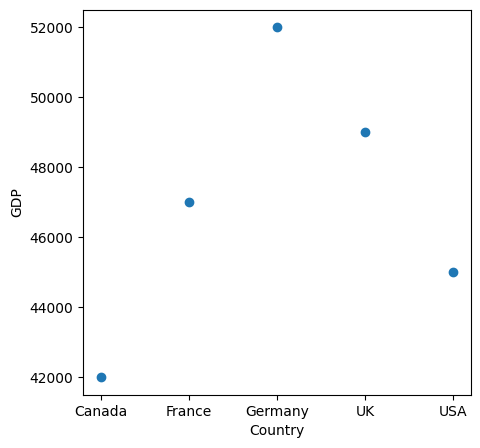

CPU times: user 206 ms, sys: 22.7 ms, total: 229 ms
Wall time: 225 ms


In [240]:
%%time

import matplotlib.pyplot as plt

data = [('USA', 45000), ('Canada', 42000), ('Germany', 52000), ('UK', 49000), ('France', 47000)]
spark = create_sail_session("GDP Data Analysis")
df = spark.createDataFrame(data, ['Country', 'GDP'])
rows = df.orderBy('Country').collect()
xs = [r['Country'] for r in rows]
ys = [r['GDP'] for r in rows]

plt.figure(figsize=(5, 5))
plt.scatter(xs, ys)
plt.xlabel('Country')
plt.ylabel('GDP')
plt.show()

# line

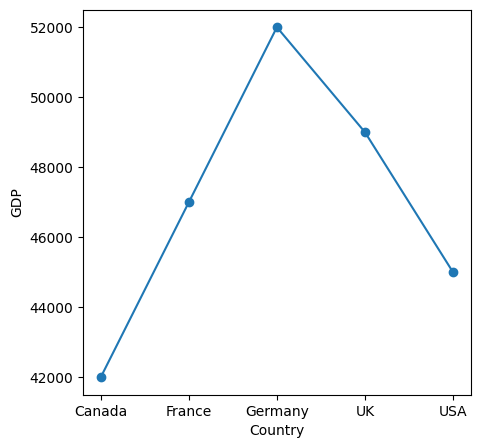

CPU times: user 366 ms, sys: 27.3 ms, total: 393 ms
Wall time: 391 ms


In [241]:
%%time

import matplotlib.pyplot as plt

data = [('USA', 45000), ('Canada', 42000), ('Germany', 52000), ('UK', 49000), ('France', 47000)]
spark = create_sail_session("GDP Data Analysis")
df = spark.createDataFrame(data, ['Country', 'GDP'])
rows = df.orderBy('Country').collect()
xs = [r['Country'] for r in rows]
ys = [r['GDP'] for r in rows]

plt.figure(figsize=(5, 5))
plt.plot(xs, ys, marker='o')
plt.xlabel('Country')
plt.ylabel('GDP')
plt.show()

## pie

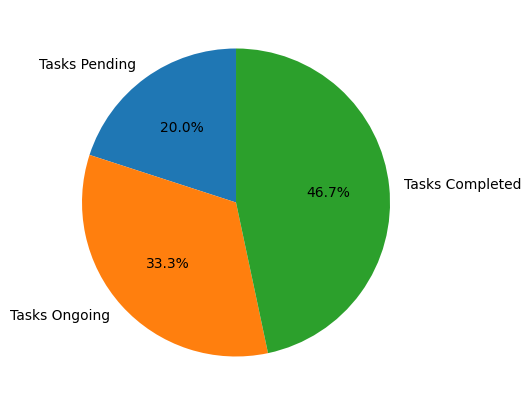

CPU times: user 118 ms, sys: 12.2 ms, total: 130 ms
Wall time: 126 ms


In [242]:
%%time

import matplotlib.pyplot as plt

data = [('Tasks Pending', 300), ('Tasks Ongoing', 500), ('Tasks Completed', 700)]
spark = create_sail_session("Tasks Data Analysis")
df = spark.createDataFrame(data, ['Label', 'Tasks'])
rows = df.collect()
labels = [r['Label'] for r in rows]
values = [r['Tasks'] for r in rows]

plt.figure(figsize=(5, 5))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.show()

## Groupby

### PETS

+----+---+------+----------+------------+--------+
|name|age|gender|     state|num_children|num_pets|
+----+---+------+----------+------------+--------+
|john| 23|     M|california|           2|       5|
|mary| 78|     F|        dc|           0|       1|
+----+---+------+----------+------------+--------+
only showing top 2 rows

Scatter


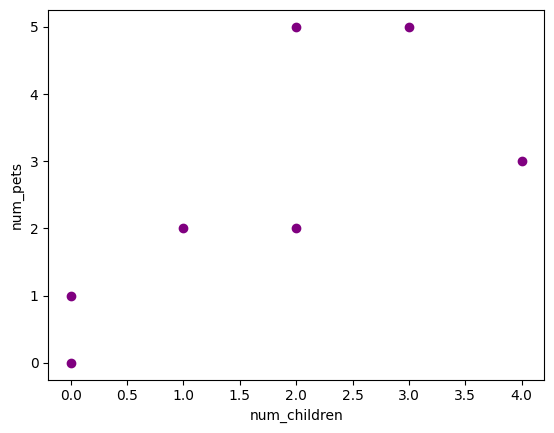

Lines children | pets


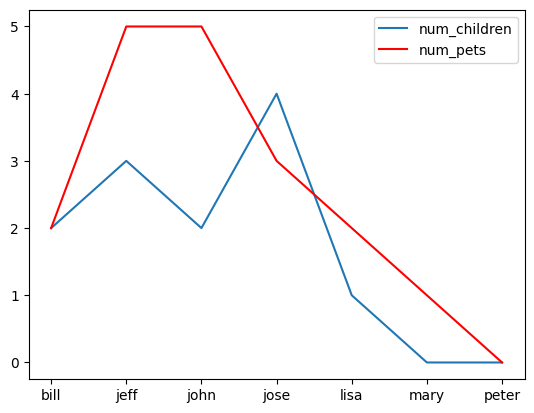

Bar group by children


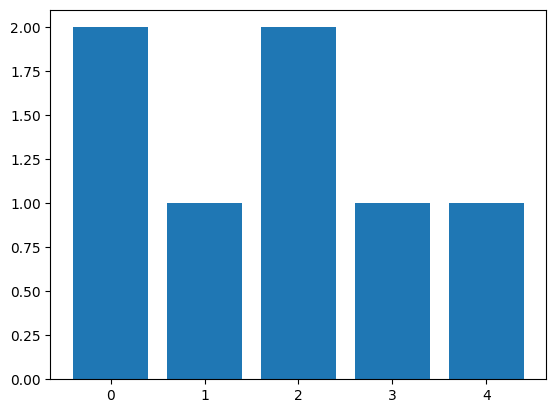

Bar group by pets


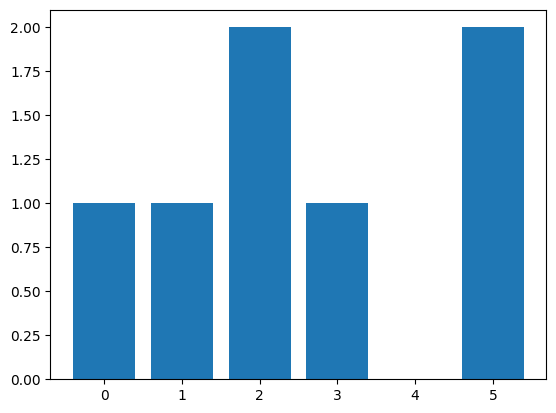

Bar group by state


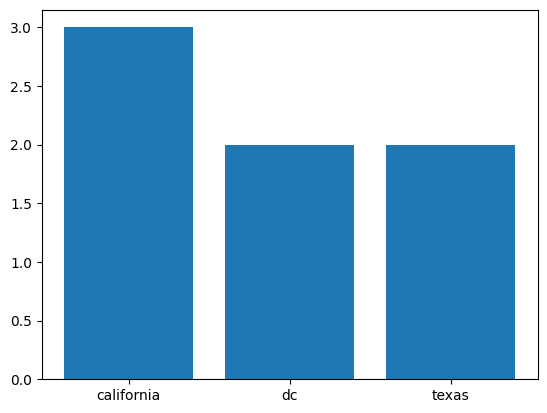

CPU times: user 1.04 s, sys: 57.6 ms, total: 1.1 s
Wall time: 1.1 s


In [243]:
%%time

import matplotlib.pyplot as plt
spark = create_sail_session("Pets Data Analysis")
pets = spark.createDataFrame([
    ('john', 23, 'M', 'california', 2, 5),
    ('mary', 78, 'F', 'dc', 0, 1),
    ('peter', 22, 'M', 'california', 0, 0),
    ('jeff', 19, 'M', 'dc', 3, 5),
    ('bill', 45, 'M', 'california', 2, 2),
    ('lisa', 33, 'F', 'texas', 1, 2),
    ('jose', 20, 'M', 'texas', 4, 3),
], ['name', 'age', 'gender', 'state', 'num_children', 'num_pets'])

pets.show(2)

print('Scatter')
pts = pets.select('num_children', 'num_pets').collect()
plt.scatter([r['num_children'] for r in pts], [r['num_pets'] for r in pts], color='purple')
plt.xlabel('num_children')
plt.ylabel('num_pets')
plt.show()

print('Lines children | pets')
rows = pets.orderBy('name').select('name', 'num_children', 'num_pets').collect()
names = [r['name'] for r in rows]
children = [r['num_children'] for r in rows]
petn = [r['num_pets'] for r in rows]
plt.plot(names, children, label='num_children')
plt.plot(names, petn, color='red', label='num_pets')
plt.legend()
plt.show()

print('Bar group by children')
ch = pets.groupBy('num_children').count().orderBy('num_children').collect()
plt.bar([r['num_children'] for r in ch], [r['count'] for r in ch])
plt.show()

print('Bar group by pets')
pp = pets.groupBy('num_pets').count().orderBy('num_pets').collect()
plt.bar([r['num_pets'] for r in pp], [r['count'] for r in pp])
plt.show()

print('Bar group by state')
st = pets.groupBy('state').count().orderBy('state').collect()
plt.bar([r['state'] for r in st], [r['count'] for r in st])
plt.show()

# GraphX

In [244]:
%%time

from graphframes import GraphFrame

spark = create_sail_session("GraphFramesExample")

# Crea vertici e archi come DataFrame
nodes = [
    (1, "A", 30),
    (2, "B", 25),
    (3, "C", 35)
]
nodes_df = spark.createDataFrame(nodes, ["id", "name", "age"])

edges = [
    (1, 2, "--->"),
    (2, 1, "--->"),
    (2, 3, "--->"),
    (3, 2, "<---")  
]
edges_df = spark.createDataFrame(edges, ["src", "dst", "relationship"])

g = GraphFrame(nodes_df, edges_df)

g.inDegrees.show()
g.outDegrees.show()
g.degrees.show()

PySparkAttributeError: [ATTRIBUTE_NOT_SUPPORTED] Attribute `sql_ctx` is not supported.

# MLlib

In [245]:
%%time

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator



spark = create_sail_session("MLlibExample")


# Dataset di esempio
data = spark.createDataFrame([
    (1.0, 2.0, 3.0), (2.0, 4.0, 5.0), (3.0, 6.0, 7.0),
    (4.0, 8.0, 9.0), (5.0, 10.0, 11.0)
], ["feature1", "feature2", "label"])

# Assemblaggio feature
assembler = VectorAssembler(inputCols=["feature1", "feature2"], outputCol="features")
df = assembler.transform(data)

# Split train/test
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

# Addestramento modello
lr = LinearRegression(labelCol="label", featuresCol="features", maxIter=10)
model = lr.fit(train_df)

# Predizioni
predictions = model.transform(test_df)
predictions.select("label", "prediction").show()

# Valutazione RMSE
evaluator = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
rmse = evaluator.evaluate(predictions)
print(f"RMSE: {rmse}")

UnsupportedOperationException: ml command

# Spark Structured Streaming

In [246]:
%%time

from pyspark.sql import SparkSession
from pyspark.sql.functions import explode, split
import random
import socket
import threading
import time

WORDS = ["spark", "streaming", "data", "graph",
         "mllib", "urandom", "test",
         "example", "demo", "sample",
         "towards", "expressions"]


def start_server(host="localhost", port=29999, interval=1):
    server = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    server.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
    server.bind((host, port))
    server.listen(1)
    print(f"[Server] Listening on {host}:{port}...")

    def handle_client(conn):
        try:
            while True:
                line = " ".join(random.choices(WORDS, k=5)) + "\n"
                conn.sendall(line.encode("utf-8"))
                time.sleep(interval)
        except (BrokenPipeError, ConnectionResetError):
            print("[Server] Client disconnected.")

    while True:
        conn, addr = server.accept()
        print(f"[Server] Client connected: {addr}")
        threading.Thread(target=handle_client, args=(conn,), daemon=True).start()



server_thread = threading.Thread(
    target=start_server,
    kwargs={"host": "localhost", "port": 29999, "interval": 1},
    daemon=True
)
server_thread.start()
time.sleep(2)  # wait to establish connection


# --- 2. Spark Structured Streaming ---
spark = create_sail_session("StructuredStreaming")



lines = spark.readStream \
    .format("socket") \
    .option("host", "localhost") \
    .option("port", 29999) \
    .load()

words = lines.select(explode(split(lines.value, " ")).alias("word"))
word_counts = words.groupBy("word").count()

query = word_counts.writeStream \
    .outputMode("complete") \
    .format("console") \
    .option("truncate", False) \
    .trigger(processingTime="5 seconds") \
    .start()

#query.awaitTermination()
try:
    query.awaitTermination(timeout=2)
except Exception as e:
    print(f"[Query] Terminated with: {e}")
finally:
    print("[Main] Stopping query...")
    query.stop()
    print("[Main] Stopping SparkSession...")
    spark.stop()
    print("[Main] Done.")


Exception in thread Thread-226 (start_server):
Traceback (most recent call last):
  File "/home/simone/.pyenv/versions/3.10.21/lib/python3.10/threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "/home/simone/.pyenv/versions/3.10.21/lib/python3.10/threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "<timed exec>", line 17, in start_server
OSError: [Errno 98] Address already in use


UnsupportedOperationException: streaming unnest: Unnest(Unnest { input: Projection(Projection { expr: [Column(Column { relation: None, name: "_marker" }), Column(Column { relation: None, name: "_retracted" }), Alias(Alias { expr: ScalarFunction(ScalarFunction { func: ScalarUDF { inner: SparkSplit { signature: Signature { type_signature: UserDefined, volatility: Immutable, parameter_names: None } } }, args: [Column(Column { relation: Some(Bare { table: "?table?" }), name: "value" }), Literal(Utf8(" "), None), Literal(Int32(-1), None)] }), relation: None, name: "#1", metadata: None })], input: Extension(Extension { node: StreamSourceWrapperNode { source: SocketStreamSource { options: SocketReadOptions { host: "localhost", port: 29999, max_batch_size: 1000, timeout_sec: 1 }, schema: Schema { fields: [Field { name: "value", data_type: Utf8 }], metadata: {} } }, names: None, schema: DFSchema { inner: Schema { fields: [Field { name: "_marker", data_type: Binary, nullable: true }, Field { nam